## Toy Store E-Commerce — Analytics Report

### 1. Environment & Database Setup

**1.1 Import Libraries**

In [2]:
import time
import os
from dotenv import load_dotenv

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import plotly.io as pio
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objects as go

import duckdb

**1.2 Configrations**

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
sns.set_theme(style='whitegrid', palette='muted')

load_dotenv()
DB_PATH      = os.getenv("DB_PATH")
PG_HOST      = os.getenv("PG_HOST")
PG_DBNAME    = os.getenv("PG_DBNAME")
PG_USER      = os.getenv("PG_USER")
PG_PASSWORD  = os.getenv("PG_PASSWORD")

**1.3 ETL — Load from PostgreSQL into DuckDB**

In [7]:
con_duck = duckdb.connect(database=DB_PATH)
pg_conn_str = f"host={PG_HOST} dbname={PG_DBNAME} user={PG_USER} password={PG_PASSWORD}"

try:
    con_duck.execute("INSTALL postgres; LOAD postgres;")
    con_duck.execute(f"ATTACH '{pg_conn_str}' AS pg_source (TYPE POSTGRES);")
    
    tables_query = "SELECT table_name FROM pg_source.information_schema.tables WHERE table_schema = 'public'"
    tables = con_duck.execute(tables_query).df()['table_name'].tolist()

    print("-" * 60)
    print(f"{'Table Name':<30} | {'Status':<10} | {'Duration':<12}")
    print("-" * 60)

    for table in tables:
        start_time = time.time()    
        con_duck.execute(f'CREATE OR REPLACE TABLE "{table}" AS SELECT * FROM pg_source.public."{table}";')
        
        duration = time.time() - start_time
        print(f"{table:<30} | {'Success':<10} | {duration:>7.2f} sec")

except Exception as e:
    print(f"ETL Process Failed: {e}")

finally:
    try:
        con_duck.execute("DETACH pg_source;")
    except:
        pass

------------------------------------------------------------
Table Name                     | Status     | Duration    
------------------------------------------------------------
order_item_refunds             | Success    |    0.14 sec
order_items                    | Success    |    0.29 sec
orders                         | Success    |    0.29 sec
products                       | Success    |    0.03 sec
website_pageviews              | Success    |    1.55 sec
website_sessions               | Success    |    1.86 sec


**1.4 Connect to DuckDB**

In [7]:
DB_PATH = os.getenv("DB_PATH")
con_duck = duckdb.connect(database=DB_PATH)

tables_list = con_duck.execute('SHOW TABLES').df()['name'].tolist()

print(f'Tables available for analysis: {len(tables_list)}\n')
for i, table in enumerate(tables_list, 1):
    print(f"{i}. {table}")

Tables available for analysis: 6

1. order_item_refunds
2. order_items
3. orders
4. products
5. website_pageviews
6. website_sessions


### 2. EDA & Data Quality

**2.1 Database Overview — Table Size Summary**

In [7]:
info_table = [
    {
        'Table Name':   table,
        'Row Count':    con_duck.execute(f'SELECT COUNT(*) FROM {table}').fetchone()[0],
        'Column Count': len(con_duck.execute(f'DESCRIBE {table}').fetchall())
    }
    for table in tables_list
]

info_df = (pd.DataFrame(info_table).sort_values('Row Count', ascending=False).reset_index(drop=True))
display(info_df)

,Table Name,Row Count,Column Count
0,website_pageviews,1188124,4
1,website_sessions,472871,9
2,order_items,40025,7
3,orders,32313,8
4,order_item_refunds,1731,5
5,products,4,3


**2.2 Data Profiling & Cardinality**

In [31]:
cardinality = []

for table in tables_list:
    schema     = con_duck.execute(f'DESCRIBE {table}').fetchall()
    total_rows = con_duck.execute(f'SELECT COUNT(*) FROM {table}').fetchone()[0]
    
    for col_name, col_type, *_ in schema:
        unique = con_duck.execute(f'SELECT COUNT(DISTINCT {col_name}) FROM {table}').fetchone()[0]
        cardinality.append({
            'table': table,
            'column':col_name,
            'data_type': col_type,
            'unique_values': unique,
            'total_rows': total_rows
        })

cardinality_df = pd.DataFrame(cardinality)
cardinality_df.index += 1
display(cardinality_df)

,table,column,data_type,unique_values,total_rows
1,order_item_refunds,order_item_refund_id,INTEGER,1731,1731
2,order_item_refunds,created_at,VARCHAR,1731,1731
3,order_item_refunds,order_item_id,INTEGER,1731,1731
4,order_item_refunds,order_id,INTEGER,1723,1731
5,order_item_refunds,refund_amount_usd,FLOAT,4,1731
6,order_items,order_item_id,INTEGER,40025,40025
7,order_items,created_at,VARCHAR,32299,40025
8,order_items,order_id,INTEGER,32313,40025
9,order_items,product_id,INTEGER,4,40025
10,order_items,is_primary_item,INTEGER,2,40025


**2.3 Missing Values Audit**

In [32]:
print(f"{'Table Name':<25} | {'Column Name':<25} | {'Null Count'}")
print('-' * 70)

for table in tables_list:
    df = con_duck.execute(f'SELECT * FROM "{table}"').df()
    null_data = df.isnull().sum()    
    null_cols = null_data[null_data > 0]
    
    if not null_cols.empty:
        for col_name, count in null_cols.items():
            print(f"{table:<25} | {col_name:<25} | {count}")
    else:
        print(f"{table:<25} | {'(All Columns)':<25} | Clean ✅")

Table Name                | Column Name               | Null Count
----------------------------------------------------------------------
order_item_refunds        | (All Columns)             | Clean ✅
order_items               | (All Columns)             | Clean ✅
orders                    | (All Columns)             | Clean ✅
products                  | (All Columns)             | Clean ✅
website_pageviews         | (All Columns)             | Clean ✅
website_sessions          | (All Columns)             | Clean ✅


**2.4 Duplicate Records Check**

In [33]:
print(f"{'Table Name':<25} | {'Status':<25} | {'Duplicate Count'}")
print('-' * 75)

for table in tables_list:
    dup_count = con_duck.execute(f'SELECT COUNT(*) - COUNT(DISTINCT COLUMNS(*)) FROM {table}').fetchone()[0]
    status    = 'Clean ✅' if dup_count == 0 else 'Duplicates Found ❌'
    print(f"{table:<25} | {status:<25} | {dup_count}")

Table Name                | Status                    | Duplicate Count
---------------------------------------------------------------------------
order_item_refunds        | Clean ✅                   | 0
order_items               | Clean ✅                   | 0
orders                    | Clean ✅                   | 0
products                  | Clean ✅                   | 0
website_pageviews         | Clean ✅                   | 0
website_sessions          | Clean ✅                   | 0


**2.5 Temporal Coverage**

In [34]:
date_summary = []

for table in tables_list:
    columns = [col[0] for col in con_duck.execute(f'DESCRIBE {table}').fetchall()]
    
    if 'created_at' in columns:
        start, end = con_duck.execute(f'SELECT MIN(created_at), MAX(created_at) FROM {table}').fetchone()
    else:
        start, end = None, None
    date_summary.append({'Table Name': table, 'Start Date': start, 'End Date': end})

display(pd.DataFrame(date_summary))

,Table Name,Start Date,End Date
0,order_item_refunds,2012-04-06 11:32:43,2015-04-01 18:11:08
1,order_items,2012-03-19 10:42:46,2015-03-19 05:38:31
2,orders,2012-03-19 10:42:46,2015-03-19 05:38:31
3,products,2012-03-19 08:00:00,2014-02-05 10:00:00
4,website_pageviews,2012-03-19 08:04:16,2015-03-19 07:59:32
5,website_sessions,2012-03-19 08:04:16,2015-03-19 07:59:08


### 3. Descriptive Statistics & Business Rules Validation

**3.1 Outlier Analysis (IQR Method)**

In [35]:
outliers_results = []
exclude_cols     = ['id', 'is_', '_id']

for table in tables_list:
    cols_info    = con_duck.execute(f'DESCRIBE {table}').df()
    numeric_cols = cols_info.loc[
        cols_info['column_type'].str.contains('INT|FLOAT|DOUBLE', case=False), 'column_name'
    ].tolist()
    valid_cols = [c for c in numeric_cols if not any(e in c.lower() for e in exclude_cols)]

    for col in valid_cols:
        res = con_duck.execute(f"""
            WITH Stats AS (
                SELECT 
                    quantile_cont("{col}", 0.25) AS q1,
                    quantile_cont("{col}", 0.75) AS q3,
                    COUNT(*) AS total
                FROM "{table}"
            ),
            Boundaries AS (
                SELECT
                    q1 - 1.5 * (q3 - q1) AS lower_limit,
                    q3 + 1.5 * (q3 - q1) AS upper_limit,
                    total
                FROM Stats
            )
        SELECT 
            COUNT(*),
            COUNT(*) * 100.0 / FIRST(total)
        FROM "{table}", Boundaries WHERE "{col}" < lower_limit OR "{col}" > upper_limit
        """).fetchone()

        outliers_results.append({
            'Table': table,
            'Column': col,
            'Outliers_Count': res[0],
            'Outlier_Percentage': round(res[1], 2)})

outliers_df = (pd.DataFrame(outliers_results).sort_values('Outliers_Count', ascending=False).reset_index(drop=True))
outliers_df.index += 1
display(outliers_df)

,Table,Column,Outliers_Count,Outlier_Percentage
1,order_items,price_usd,15799,39.47
2,order_items,cogs_usd,15799,39.47
3,orders,cogs_usd,9623,29.78
4,orders,price_usd,8246,25.52
5,orders,items_purchased,7712,23.87
6,order_item_refunds,refund_amount_usd,494,28.54


**Chart — Outlier Percentage by Column**

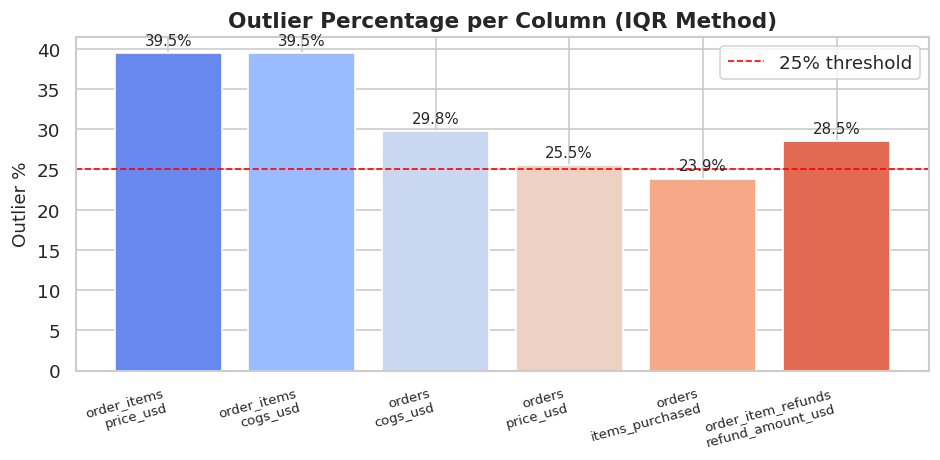

In [36]:
fig, ax = plt.subplots(figsize=(8, 4))
labels  = outliers_df['Table'] + '\n' + outliers_df['Column']
bars    = ax.bar(labels, outliers_df['Outlier_Percentage'],
                 color=sns.color_palette('coolwarm', len(outliers_df)))
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_ylabel('Outlier %')
ax.set_title('Outlier Percentage per Column (IQR Method)', fontweight='bold')
ax.axhline(25, color='red', linestyle='--', linewidth=1, label='25% threshold')
ax.legend()
plt.xticks(rotation=15, ha='right', fontsize=8)
plt.tight_layout(); plt.show()

**3.2 Business Rules & Logic Validation**

In [36]:
# 1. Negative prices
r1 = con_duck.execute('SELECT COUNT(*) FROM order_items WHERE price_usd < 0').fetchone()[0]
print(f"{'1. Negative Price Check':<30}: {'PASS' if r1==0 else 'FAIL'} ({r1} issues)")

# 2. Refund exceeds price
r2 = con_duck.execute("""
    SELECT COUNT(*) FROM order_item_refunds r
    JOIN order_items oi ON r.order_item_id = oi.order_item_id
    WHERE r.refund_amount_usd > oi.price_usd
""").fetchone()[0]
print(f"{'2. Refund Validation Check':<30}: {'PASS' if r2==0 else 'FAIL'} ({r2} issues)")

# 3. Orphan refunds
r3 = con_duck.execute("""
    SELECT COUNT(*) FROM order_item_refunds r
    LEFT JOIN order_items oi ON r.order_item_id = oi.order_item_id
    WHERE oi.order_item_id IS NULL
""").fetchone()[0]
print(f"{'3. Orphan Refund Check':<30}: {'PASS' if r3==0 else 'FAIL'} ({r3} issues)")

# 4. Loss-making products
r4 = con_duck.execute('SELECT COUNT(*) FROM order_items WHERE cogs_usd > price_usd').fetchone()[0]
print(f"{'4. Loss Product Check':<30}: {'PASS' if r4==0 else 'WARNING'} ({r4} issues)")

# 5. Unmatched dates
r5 = con_duck.execute("""
    SELECT COUNT(*) FROM orders AS o
    JOIN order_items AS o_i ON o.order_id = o_i.order_id
    WHERE o.created_at != o_i.created_at
""").fetchone()[0]
print(f"{'5. Unmatched Date Check':<30}: {'PASS' if r5==0 else 'FAIL'} ({r5} issues)")

# 6. Refund before purchase
r6 = con_duck.execute("""
    SELECT COUNT(*) FROM order_items oi
    JOIN order_item_refunds oir ON oi.order_item_id = oir.order_item_id
    WHERE oir.created_at < oi.created_at
""").fetchone()[0]
print(f"{'6. Refund Chronology Check':<30}: {'PASS' if r6==0 else 'FAIL'} ({r6} issues)")

# 7. Duplicate order items
r7 = con_duck.execute("""
    SELECT COUNT(*) FROM (
        SELECT order_item_id FROM order_items
        GROUP BY order_item_id HAVING COUNT(*) > 1
    )
""").fetchone()[0]
print(f"{'7. Duplicate Item Check':<30}: {'PASS' if r7==0 else 'FAIL'} ({r7} issues)")

# 8. Zero prices  (was mislabeled #9 in original)
r8 = con_duck.execute('SELECT COUNT(*) FROM order_items WHERE price_usd = 0').fetchone()[0]
print(f"{'8. Zero Price Check':<30}: {'PASS' if r8==0 else 'WARNING'} ({r8} issues)")

1. Negative Price Check       : PASS (0 issues)
2. Refund Validation Check    : PASS (0 issues)
3. Orphan Refund Check        : PASS (0 issues)
4. Loss Product Check         : PASS (0 issues)
5. Unmatched Date Check       : PASS (0 issues)
6. Refund Chronology Check    : PASS (0 issues)
7. Duplicate Item Check       : PASS (0 issues)
8. Zero Price Check           : PASS (0 issues)


### 4. Macro-Level Analysis

**4.1 Sales & Profitability Overview (Gross vs Net)**

In [38]:
df_metrics = con_duck.execute("""
SELECT
    COUNT(DISTINCT o.order_id) AS "Total Orders",
    COUNT(oi.order_item_id) AS "Total Items Sold",
    ROUND(SUM(oi.price_usd), 2) AS "Gross Revenue",
    ROUND(SUM(oi.cogs_usd), 2) AS "Total COGS",
    ROUND(SUM(oi.price_usd - oi.cogs_usd), 2) AS "Gross Profit",
    ROUND(COALESCE(SUM(oir.refund_amount_usd), 0), 2) AS "Total Refunds",
    ROUND(SUM(oi.price_usd) - COALESCE(SUM(oir.refund_amount_usd), 0), 2) AS "Net Revenue",
    ROUND((SUM(oi.price_usd - oi.cogs_usd) / NULLIF(SUM(oi.price_usd),0))*100,2) AS "Profit Margin %",
    ROUND(SUM(oi.price_usd) / NULLIF(COUNT(DISTINCT o.order_id),0), 2) AS "AOV (Avg Order Value)",
    ROUND(COUNT(oi.order_item_id)*1.0 / NULLIF(COUNT(DISTINCT o.order_id),0), 2) AS "Items Per Order",
    ROUND(COALESCE(SUM(oir.refund_amount_usd),0)/NULLIF(SUM(oi.price_usd),0)*100,2) AS "Refund Rate %"
FROM orders AS o JOIN order_items AS oi
ON o.order_id = oi.order_id
LEFT JOIN order_item_refunds AS oir ON oi.order_item_id = oir.order_item_id
""").df()


styled_df = df_metrics.T.rename(columns={0: 'Metric'})
styled_df

,Metric
Total Orders,32313.00
Total Items Sold,40025.00
Gross Revenue,1938509.81
Total COGS,722370.24
Gross Profit,1216139.56
Total Refunds,85338.69
Net Revenue,1853171.11
Profit Margin %,62.74
AOV (Avg Order Value),59.99
Items Per Order,1.24


**Chart — Revenue Breakdown (Gross / COGS / Refunds / Net)**

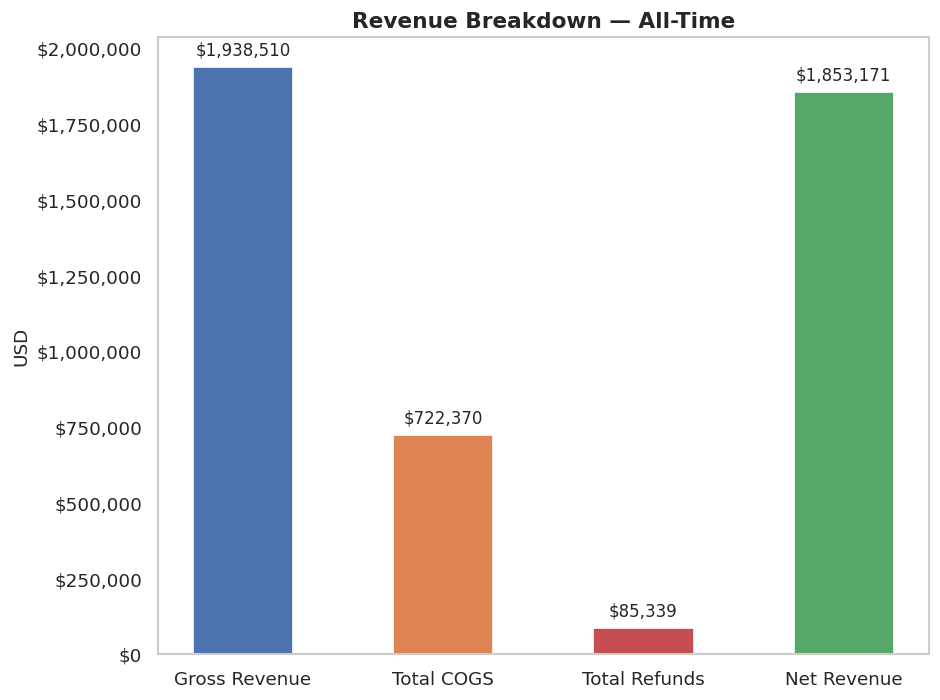

In [39]:
row    = df_metrics.iloc[0]
labels = ['Gross Revenue', 'Total COGS', 'Total Refunds', 'Net Revenue']
values = [row['Gross Revenue'], row['Total COGS'], row['Total Refunds'], row['Net Revenue']]
colors = ['#4C72B0', '#DD8452', '#C44E52', '#55A868']

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(labels, values, color=colors, width=0.5)
ax.bar_label(bars, fmt='${:,.0f}', padding=5, fontsize=10)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Revenue Breakdown — All-Time', fontweight='bold')
ax.set_ylabel('USD')
ax.grid(False)

plt.tight_layout()
plt.show()

**4.2 Yearly Performance Summary**

In [5]:
yearly_trends = con_duck.execute("""
SELECT
    EXTRACT(YEAR FROM o.created_at::TIMESTAMP) AS year,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(oi.price_usd), 2) AS revenue,
    ROUND(SUM(oi.price_usd - oi.cogs_usd), 2) AS gross_profit,
    ROUND(
        (SUM(oi.price_usd) - LAG(SUM(oi.price_usd)) OVER (ORDER BY EXTRACT(YEAR FROM o.created_at::TIMESTAMP)))
        / NULLIF(LAG(SUM(oi.price_usd)) OVER (ORDER BY EXTRACT(YEAR FROM o.created_at::TIMESTAMP)), 0) * 100, 2
    ) AS revenue_growth_pct
FROM orders AS o JOIN order_items AS oi USING (order_id)
GROUP BY 1 ORDER BY 1
""").df()

display(yearly_trends)

,year,total_orders,revenue,gross_profit,revenue_growth_pct
0,2012,2586,129274.14,78873.00,NaN
1,2013,7447,393247.88,241596.51,204.20
2,2014,16860,1075612.22,679722.53,173.52
3,2015,5420,340375.56,215947.51,-68.36


**Chart — Yearly Revenue & Gross Profit**

In [ ]:
pio.renderers.default = "png"
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(x=yearly_trends['year'].astype(str), y=yearly_trends['revenue'],
           name="Revenue", marker_color='#4C72B0',
           text=yearly_trends['revenue'], texttemplate='$%{text:,.0f}', textposition='inside'),
    secondary_y=False
)
fig.add_trace(
    go.Bar(x=yearly_trends['year'].astype(str), y=yearly_trends['gross_profit'],
           name="Gross Profit", marker_color='#55A868',
           text=yearly_trends['gross_profit'], texttemplate='$%{text:,.0f}', textposition='outside'),
    secondary_y=False
)
fig.add_trace(
    go.Scatter(x=yearly_trends['year'].astype(str), y=yearly_trends['revenue_growth_pct'],
               name="YoY Growth %", mode='lines+markers+text',
               line=dict(color='tomato', width=3),
               marker=dict(size=10),
               text=yearly_trends['revenue_growth_pct'], texttemplate='%{text:.1f}%', textposition='top right'),
    secondary_y=True
)

fig.update_layout(
    title_text='Annual Financial Performance & Growth Velocity',
    template='plotly_white',
    barmode='group',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.update_yaxes(title_text="USD Amount ($)", secondary_y=False)
fig.update_yaxes(title_text="Growth Rate (%)", secondary_y=True, range=[0, 100])

fig.show(renderer="png", width=1000, height=600, scale=2)

**4.3 Monthly Revenue & Growth Trends**

In [42]:
monthly_trends = con_duck.execute("""
    SELECT
        DATE_TRUNC('month', o.created_at::TIMESTAMP)::DATE AS month,
        COUNT(DISTINCT o.order_id) AS total_orders,
        ROUND(SUM(oi.price_usd), 2) AS revenue,
        ROUND(SUM(oi.price_usd - oi.cogs_usd), 2) AS gross_profit,
        ROUND(SUM(oi.price_usd) / NULLIF(COUNT(DISTINCT o.order_id), 0), 2) AS aov
    FROM orders AS o 
    JOIN order_items oi USING (order_id)
    GROUP BY 1 ORDER BY 1
""").df()
monthly_trends['month'] = pd.to_datetime(monthly_trends['month'])
monthly_trends['revenue_growth_pct'] = monthly_trends['revenue'].pct_change() * 100

display(monthly_trends[:10])

,month,total_orders,revenue,gross_profit,aov,revenue_growth_pct
0,2012-03-01,60,2999.40,1830.0,49.99,NaN
1,2012-04-01,99,4949.01,3019.5,49.99,65.000000
2,2012-05-01,108,5398.92,3294.0,49.99,9.090909
3,2012-06-01,140,6998.60,4270.0,49.99,29.629630
4,2012-07-01,169,8448.31,5154.5,49.99,20.714286
5,2012-08-01,228,11397.72,6954.0,49.99,34.911243
6,2012-09-01,287,14347.13,8753.5,49.99,25.877193
7,2012-10-01,371,18546.29,11315.5,49.99,29.268293
8,2012-11-01,618,30893.82,18849.0,49.99,66.576819
9,2012-12-01,506,25294.94,15433.0,49.99,-18.122977


**Chart — Monthly Revenue Trend (2012–2015)**

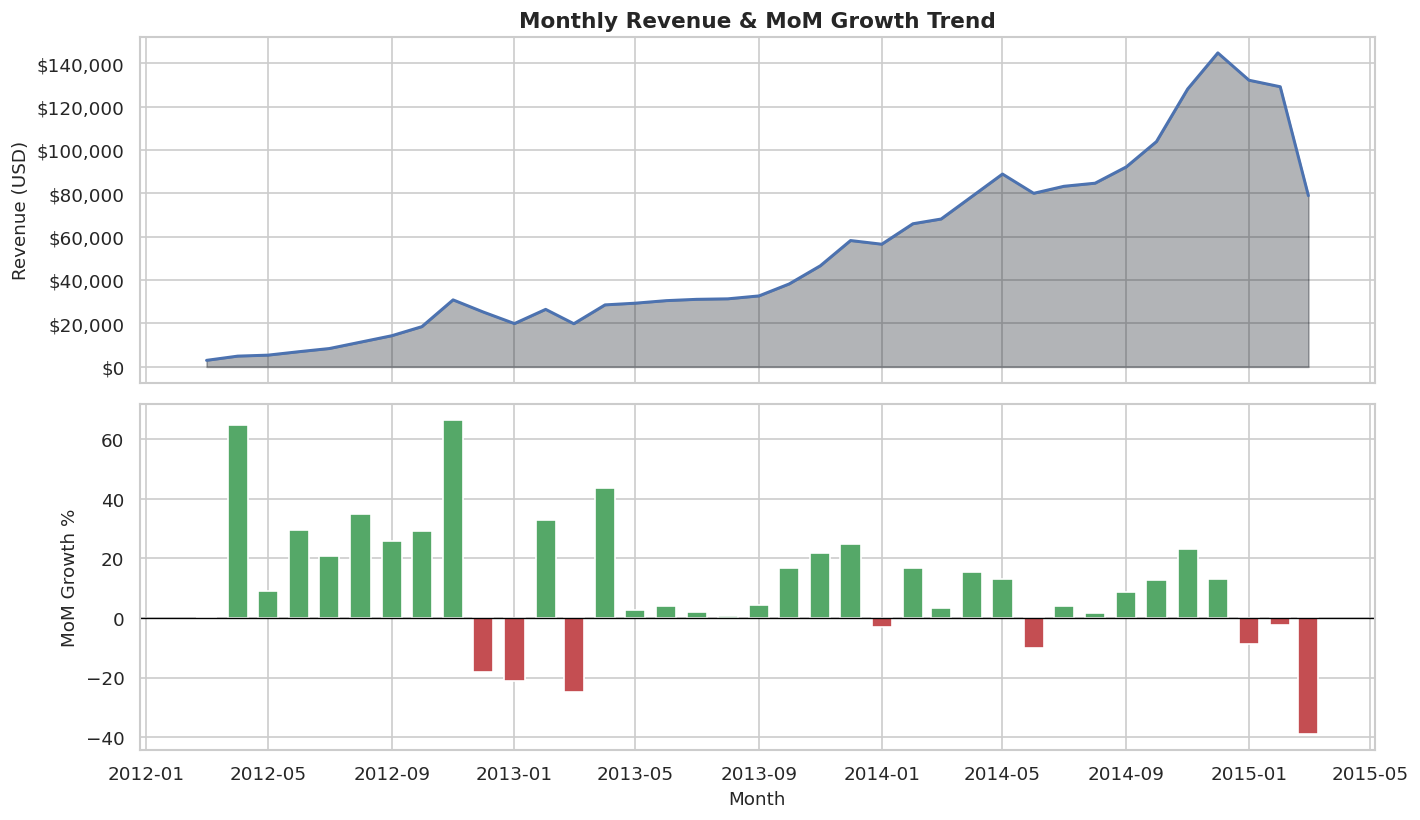

In [43]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.fill_between(monthly_trends['month'], monthly_trends['revenue'], alpha=0.3, color="#010711")
ax1.plot(monthly_trends['month'], monthly_trends['revenue'], color='#4C72B0', linewidth=1.8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax1.set_ylabel('Revenue (USD)')
ax1.set_title('Monthly Revenue & MoM Growth Trend', fontweight='bold')

colors_bar = ['#C44E52' if v < 0 else '#55A868'
              for v in monthly_trends['revenue_growth_pct'].fillna(0)]
ax2.bar(monthly_trends['month'], monthly_trends['revenue_growth_pct'].fillna(0),
        color=colors_bar, width=20)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('MoM Growth %')
ax2.set_xlabel('Month')

plt.tight_layout()
plt.show()

**4.4 Top Products by Revenue & Margin**

In [44]:
top_products = con_duck.execute("""
    SELECT
        p.product_name,
        COUNT(oi.order_item_id) AS items_sold,
        ROUND(SUM(oi.price_usd), 2) AS revenue,
        ROUND(SUM(oi.price_usd - oi.cogs_usd), 2) AS gross_profit,
        ROUND((SUM(oi.price_usd - oi.cogs_usd) / SUM(oi.price_usd)) * 100, 2) AS margin_pct
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    GROUP BY 1 ORDER BY revenue DESC
""").df()

display(top_products)

,product_name,items_sold,revenue,gross_profit,margin_pct
0,The Original Mr. Fuzzy,24226,1211057.78,738893.05,61.01
1,The Forever Love Bear,5796,347702.05,217350.00,62.51
2,The Birthday Sugar Panda,4985,229260.16,157027.51,68.49
3,The Hudson River Mini bear,5018,150489.82,102869.00,68.36


**Chart — Product Revenue & Gross Margin %**

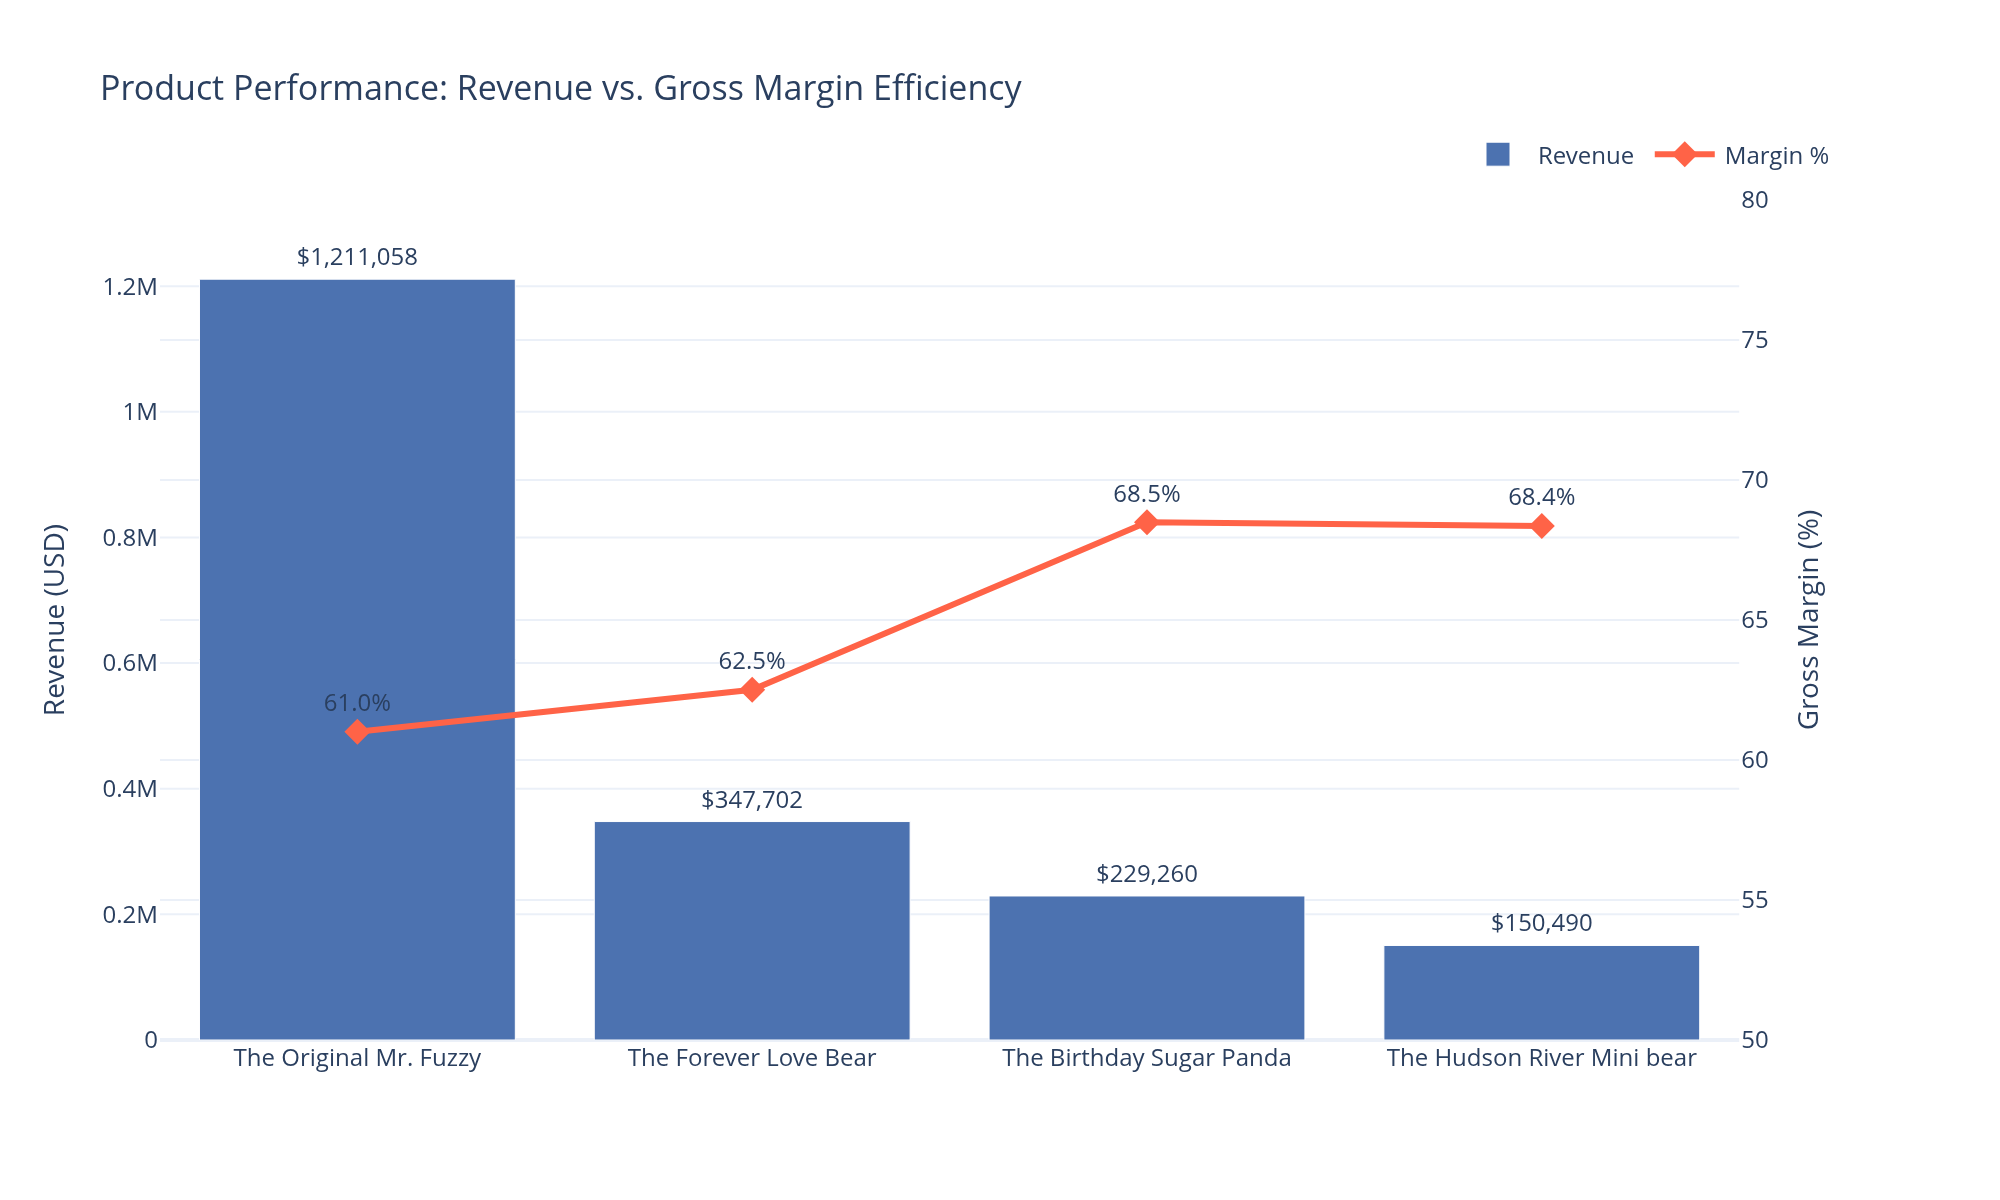

In [45]:
pio.renderers.default = "png"
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x=top_products['product_name'], 
        y=top_products['revenue'],
        name='Revenue',
        marker_color='#4C72B0',
        text=top_products['revenue'],
        texttemplate='$%{text:,.0f}',
        textposition='outside'
    ),
    secondary_y=False
)
fig.add_trace(
    go.Scatter(
        x=top_products['product_name'], 
        y=top_products['margin_pct'],
        name='Margin %',
        mode='lines+markers+text',
        line=dict(color='tomato', width=3),
        marker=dict(size=10, symbol='diamond'),
        text=top_products['margin_pct'],
        texttemplate='%{text:.1f}%',
        textposition='top center'
    ),
    secondary_y=True
)

fig.update_layout(
    title_text='Product Performance: Revenue vs. Gross Margin Efficiency',
    template='plotly_white',
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.update_yaxes(title_text="Revenue (USD)", secondary_y=False)
fig.update_yaxes(title_text="Gross Margin (%)", secondary_y=True, range=[50, 80])

fig.show(renderer="png", width=1000, height=600, scale=2)

**4.5 Traffic Source Efficiency (Conversion Rate)**

In [46]:
traffic_efficiency = con_duck.execute("""
    SELECT
        CASE WHEN utm_source = 'NULL' THEN 'direct' ELSE utm_source END AS utm_source,
        CASE WHEN utm_campaign = 'NULL' THEN 'direct' ELSE utm_campaign END AS utm_campaign,
        COUNT(DISTINCT s.website_session_id) AS total_sessions,
        COUNT(DISTINCT o.order_id) AS total_orders,
        ROUND(COUNT(DISTINCT o.order_id)*100.0 / NULLIF(COUNT(DISTINCT s.website_session_id), 0), 2) AS conv_rate
    FROM website_sessions s
    LEFT JOIN orders o ON s.website_session_id = o.website_session_id
    GROUP BY 1, 2 
    ORDER BY total_sessions DESC
""").df()

traffic_efficiency['label'] = traffic_efficiency['utm_source'] + " / " + traffic_efficiency['utm_campaign']
display(traffic_efficiency)

,utm_source,utm_campaign,total_sessions,total_orders,conv_rate,label
0,gsearch,nonbrand,282706,18822,6.66,gsearch / nonbrand
1,direct,direct,83328,6118,7.34,direct / direct
2,bsearch,nonbrand,54909,3818,6.95,bsearch / nonbrand
3,gsearch,brand,33329,2511,7.53,gsearch / brand
4,bsearch,brand,7914,701,8.86,bsearch / brand
5,socialbook,desktop_targeted,5590,288,5.15,socialbook / desktop_targeted
6,socialbook,pilot,5095,55,1.08,socialbook / pilot


**Chart — Traffic Source: Sessions vs Conversion Rate**

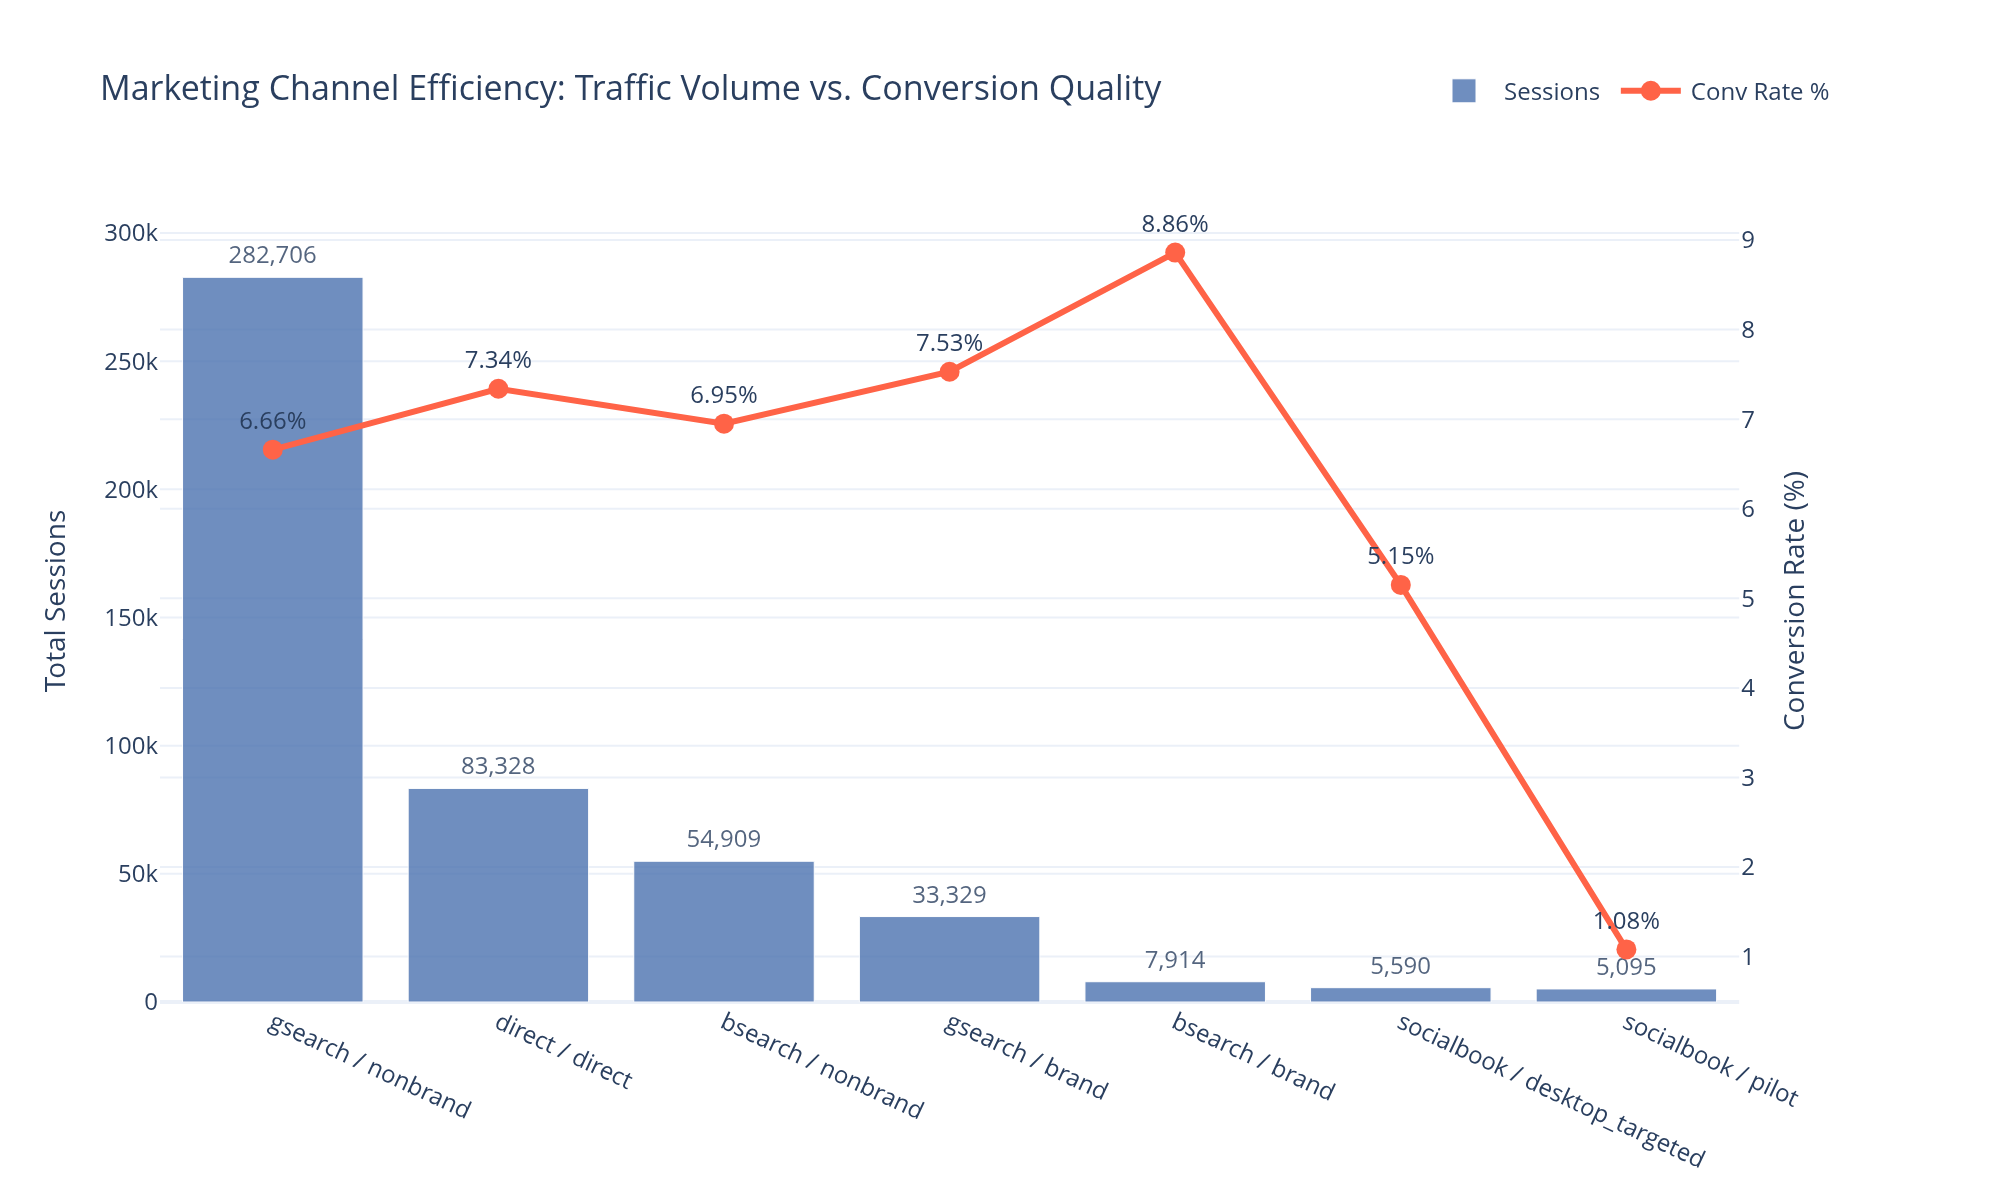

In [47]:
pio.renderers.default = "png"
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x=traffic_efficiency['label'], 
        y=traffic_efficiency['total_sessions'],
        name='Sessions',
        marker_color='#4C72B0',
        opacity=0.8,
        text=traffic_efficiency['total_sessions'],
        texttemplate='%{text:,.0f}',
        textposition='outside'
    ),
    secondary_y=False
)
fig.add_trace(
    go.Scatter(
        x=traffic_efficiency['label'], 
        y=traffic_efficiency['conv_rate'],
        name='Conv Rate %',
        mode='lines+markers+text',
        line=dict(color='tomato', width=3),
        marker=dict(size=10),
        text=traffic_efficiency['conv_rate'],
        texttemplate='%{text:.2f}%',
        textposition='top center'
    ),
    secondary_y=True
)

fig.update_layout(
    title_text='Marketing Channel Efficiency: Traffic Volume vs. Conversion Quality',
    template='plotly_white',
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.1, xanchor="right", x=1)
)

fig.update_yaxes(title_text="Total Sessions", secondary_y=False)
fig.update_yaxes(title_text="Conversion Rate (%)", secondary_y=True)
fig.update_xaxes(tickangle=25)

fig.show(renderer="png", width=1000, height=600, scale=2)

**4.6 Device Performance Gap**

In [48]:
device_performance = con_duck.execute("""
    SELECT
        s.device_type,
        COUNT(DISTINCT s.website_session_id) AS sessions,
        COUNT(DISTINCT o.order_id) AS orders,
        ROUND(COUNT(DISTINCT o.order_id)*100.0 / COUNT(DISTINCT s.website_session_id), 2) AS conv_rate
    FROM website_sessions s
    LEFT JOIN orders o ON s.website_session_id = o.website_session_id
    GROUP BY 1
""").df()

display(device_performance)

,device_type,sessions,orders,conv_rate
0,mobile,145844,4508,3.09
1,desktop,327027,27805,8.50


**Chart — Device Performance: Mobile vs Desktop**

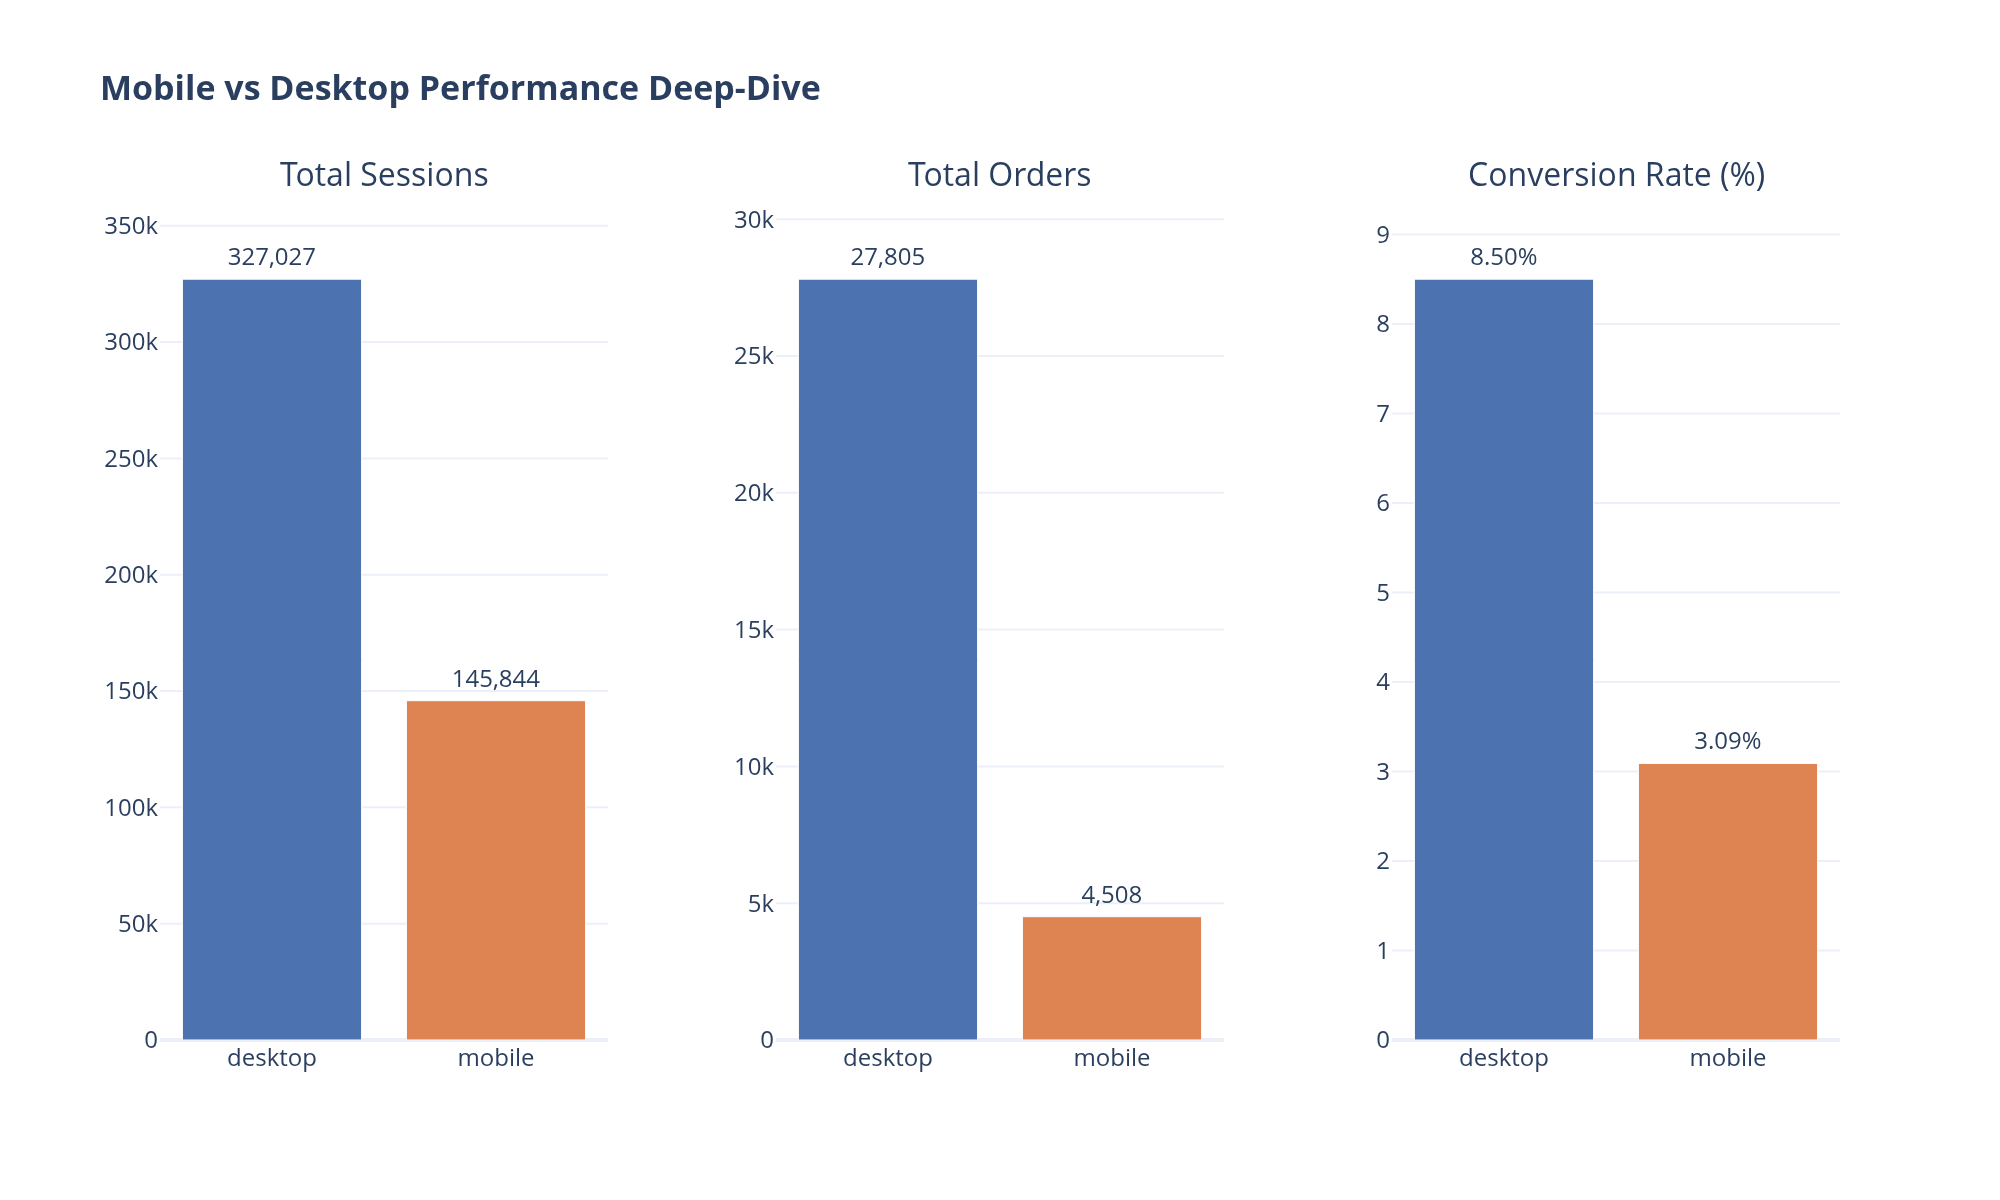

In [49]:
pio.renderers.default = "png"
dp = device_performance.sort_values('device_type')
metrics = [
    ('sessions', 'Total Sessions', '{:,.0f}'),
    ('orders', 'Total Orders', '{:,.0f}'),
    ('conv_rate', 'Conversion Rate (%)', '{:.2f}%')
]

fig = make_subplots(
    rows=1, cols=3, 
    subplot_titles=[m[1] for m in metrics],
    horizontal_spacing=0.1
)

colors = ['#4C72B0', '#DD8452']

for i, (col, title, fmt) in enumerate(metrics, 1):
    fig.add_trace(
        go.Bar(
            x=dp['device_type'], 
            y=dp[col],
            marker_color=colors,
            text=dp[col],
            texttemplate=fmt.replace('{:', '%{y:'), 
            textposition='outside',
            name=title,
            showlegend=False
        ),
        row=1, col=i
    )

fig.update_layout(
    title_text='<b>Mobile vs Desktop Performance Deep-Dive</b>',
    template='plotly_white',
    height=500,
    margin=dict(t=100)
)
fig.update_xaxes(showgrid=False)

fig.show(renderer="png", width=1000, height=600, scale=2)

### 5. Micro-Level Analysis

#### Group 1 — Revenue & Profitability Deep Dive

**Q1 — In November and December 2014 (peak season), what is the difference in profit margin between 'The Original Mr. Fuzzy' and 'The Birthday Sugar Panda', and which product was more profitable after accounting for refunds?**

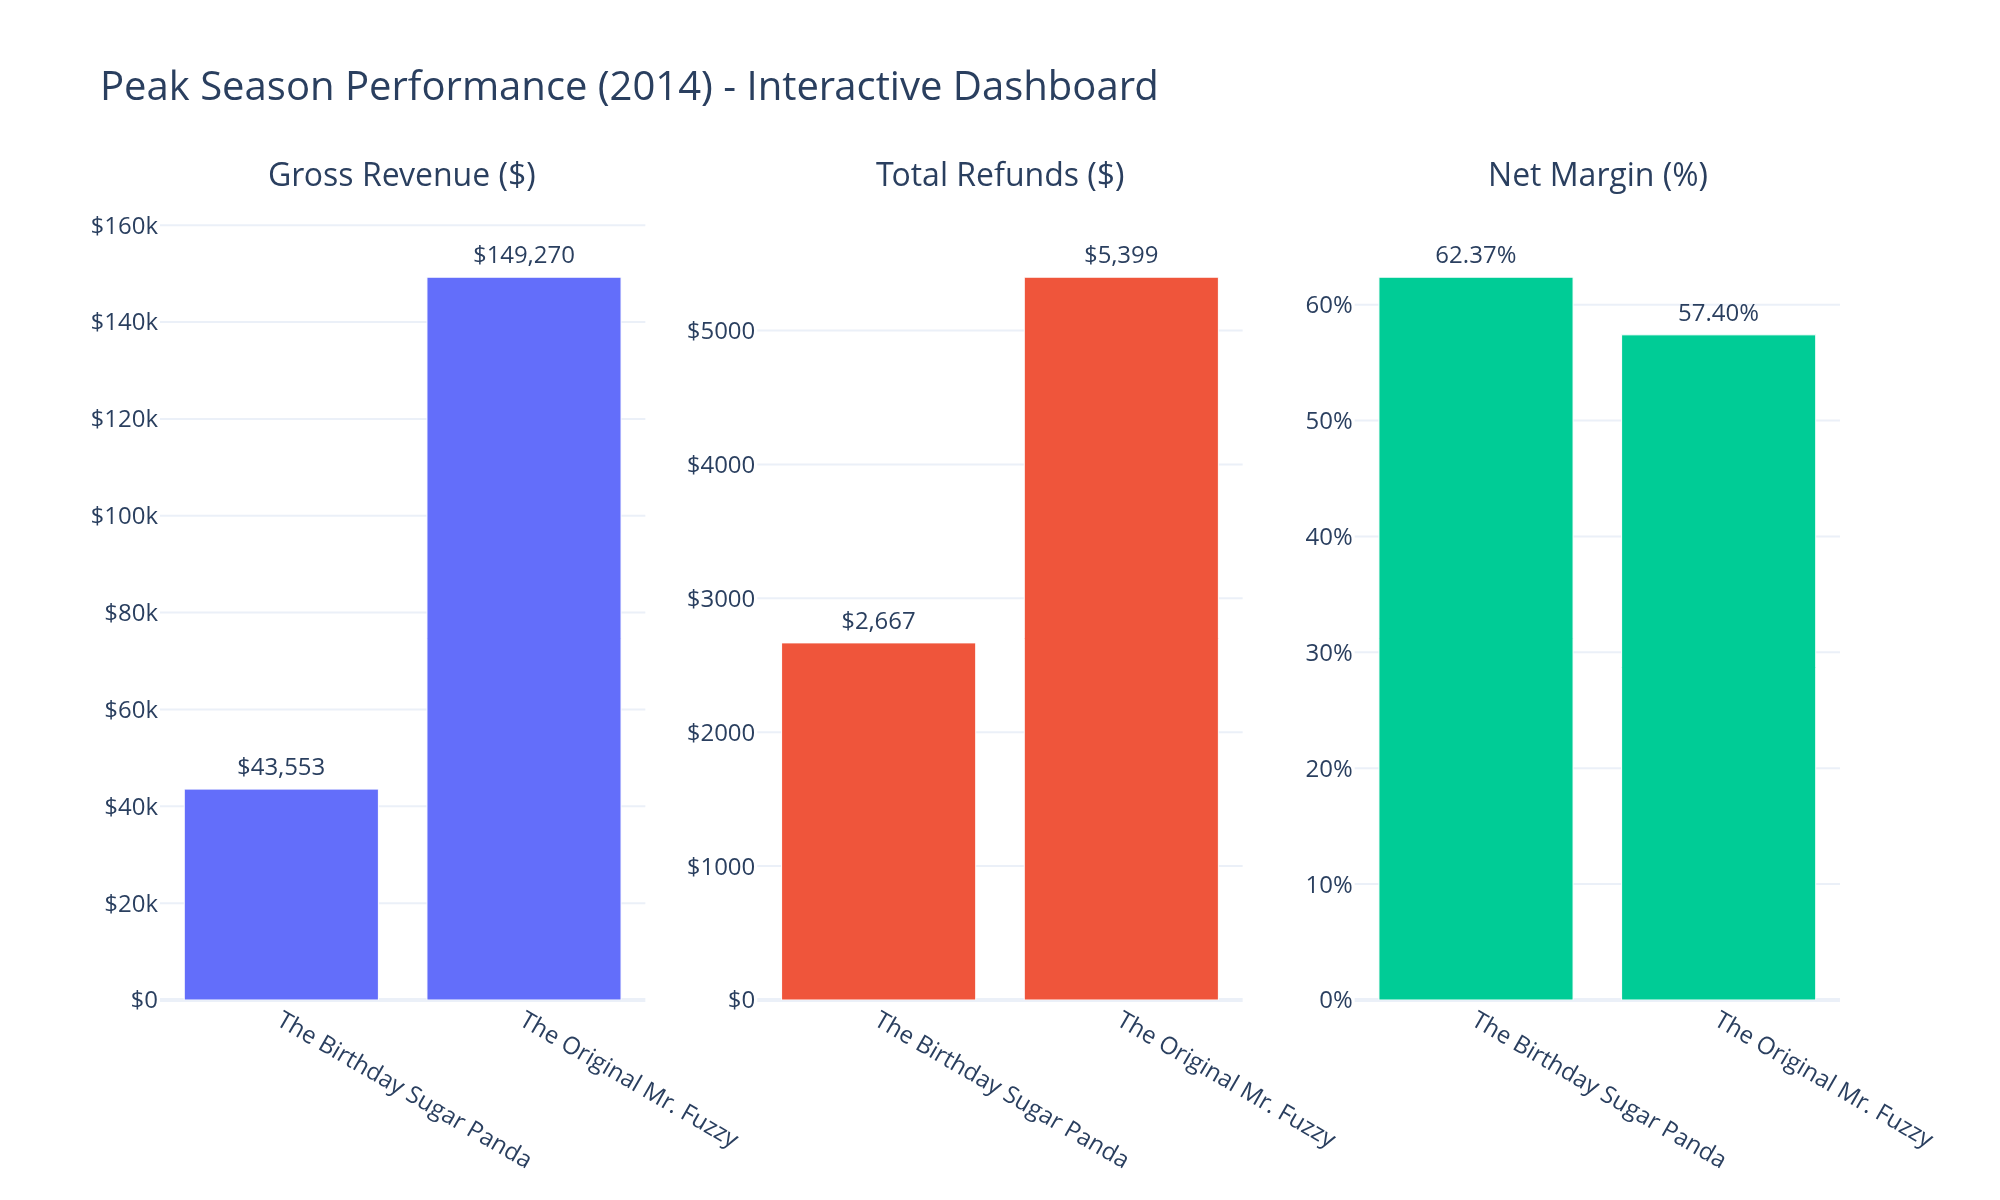

In [50]:
pio.renderers.default = "png"
q1 = con_duck.execute("""
    SELECT
        p.product_name,
        SUM(oi.price_usd) AS gross_revenue,
        SUM(COALESCE(oir.refund_amount_usd, 0)) AS total_refunds,
        SUM(oi.price_usd - oi.cogs_usd) AS gross_profit
    FROM order_items AS oi 
    JOIN products AS p USING (product_id)
    JOIN orders AS o USING (order_id)
    LEFT JOIN order_item_refunds AS oir USING (order_item_id)
    WHERE o.created_at BETWEEN '2014-11-01' AND '2014-12-31'
      AND p.product_name IN ('The Original Mr. Fuzzy', 'The Birthday Sugar Panda')
    GROUP BY 1
""").df()
q1['net_margin_pct'] = ((q1['gross_profit'] - q1['total_refunds']) / q1['gross_revenue']) * 100


fig = make_subplots(rows=1, cols=3, 
                    subplot_titles=('Gross Revenue ($)', 'Total Refunds ($)', 'Net Margin (%)'))

fig.add_trace(go.Bar(x=q1['product_name'], y=q1['gross_revenue'], name='Revenue',
                     text=q1['gross_revenue'], texttemplate='$%{text:,.0f}', textposition='outside'), row=1, col=1)
fig.add_trace(go.Bar(x=q1['product_name'], y=q1['total_refunds'], name='Refunds',
                     text=q1['total_refunds'], texttemplate='$%{text:,.0f}', textposition='outside'), row=1, col=2)
fig.add_trace(go.Bar(x=q1['product_name'], y=q1['net_margin_pct'], name='Margin',
                     text=q1['net_margin_pct'], texttemplate='%{text:.2f}%', textposition='outside'), row=1, col=3)

fig.update_layout(
    title_text='Peak Season Performance (2014) - Interactive Dashboard',
    title_font_size=20,
    showlegend=False,
    height=500,
    template='plotly_white'
)

fig.update_yaxes(tickprefix="$", row=1, col=1)
fig.update_yaxes(tickprefix="$", row=1, col=2)
fig.update_yaxes(ticksuffix="%", row=1, col=3)

fig.show(renderer="png", width=1000, height=600, scale=2)

**Q2 — Between July and September 2013 (post 204% growth spike), which products had a disproportionately high refund rate relative to their sales volume?**

/tmp/ipykernel_9389/4147123476.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(q2['product_name'], rotation=15, ha='right')


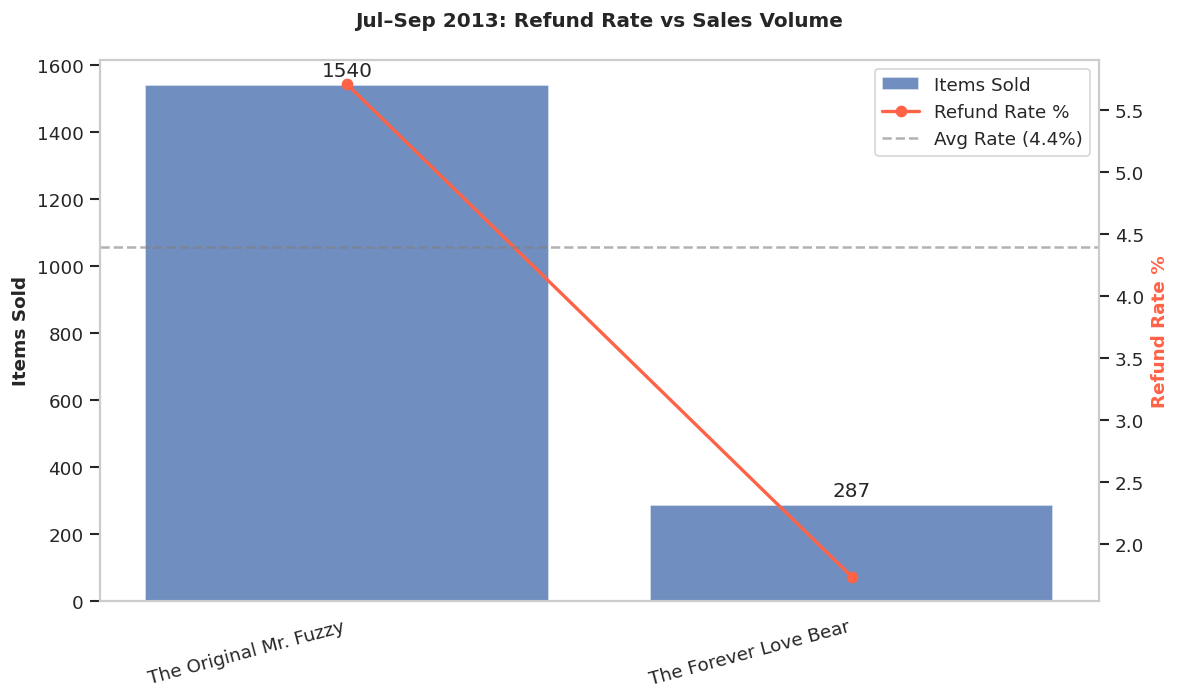

In [51]:
q2 = con_duck.execute("""
    SELECT
        product_name,
        COUNT(oi.order_item_id) AS items_sold,
        COUNT(oir.order_item_refund_id) AS refunds,
        ROUND(COUNT(oir.order_item_refund_id) * 100.0 / NULLIF(COUNT(oi.order_item_id), 0), 2) AS refund_rate_pct
    FROM order_items oi
    JOIN products USING (product_id)
    JOIN orders o USING (order_id)
    LEFT JOIN order_item_refunds oir USING (order_item_id)
    WHERE o.created_at BETWEEN '2013-07-01' AND '2013-09-30'
    GROUP BY 1 
    ORDER BY refund_rate_pct DESC
""").df()


fig, ax1 = plt.subplots(figsize=(10, 6))

bars = ax1.bar(q2['product_name'], q2['items_sold'], color='#4C72B0', alpha=0.8, label='Items Sold')
ax1.bar_label(bars, padding=3)
ax1.set_ylabel('Items Sold', fontweight='bold')
ax1.set_xticklabels(q2['product_name'], rotation=15, ha='right')
ax1.grid(False)

ax2 = ax1.twinx()
ax2.plot(q2['product_name'], q2['refund_rate_pct'], color='tomato', marker='o', lw=2, label='Refund Rate %')
ax2.axhline(4.4, color='gray', ls='--', alpha=0.6, label='Avg Rate (4.4%)')
ax2.set_ylabel('Refund Rate %', color='tomato', fontweight='bold')
ax2.grid(False)

fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.title('Jul–Sep 2013: Refund Rate vs Sales Volume', fontsize=12, fontweight='bold', pad=20)
plt.grid(visible=False)
plt.tight_layout()
plt.show()

**Q3 — In 2014 (the highest revenue year at $1.07M), which three months generated the most gross profit, and did their AOV exceed the yearly average of $63.80?**

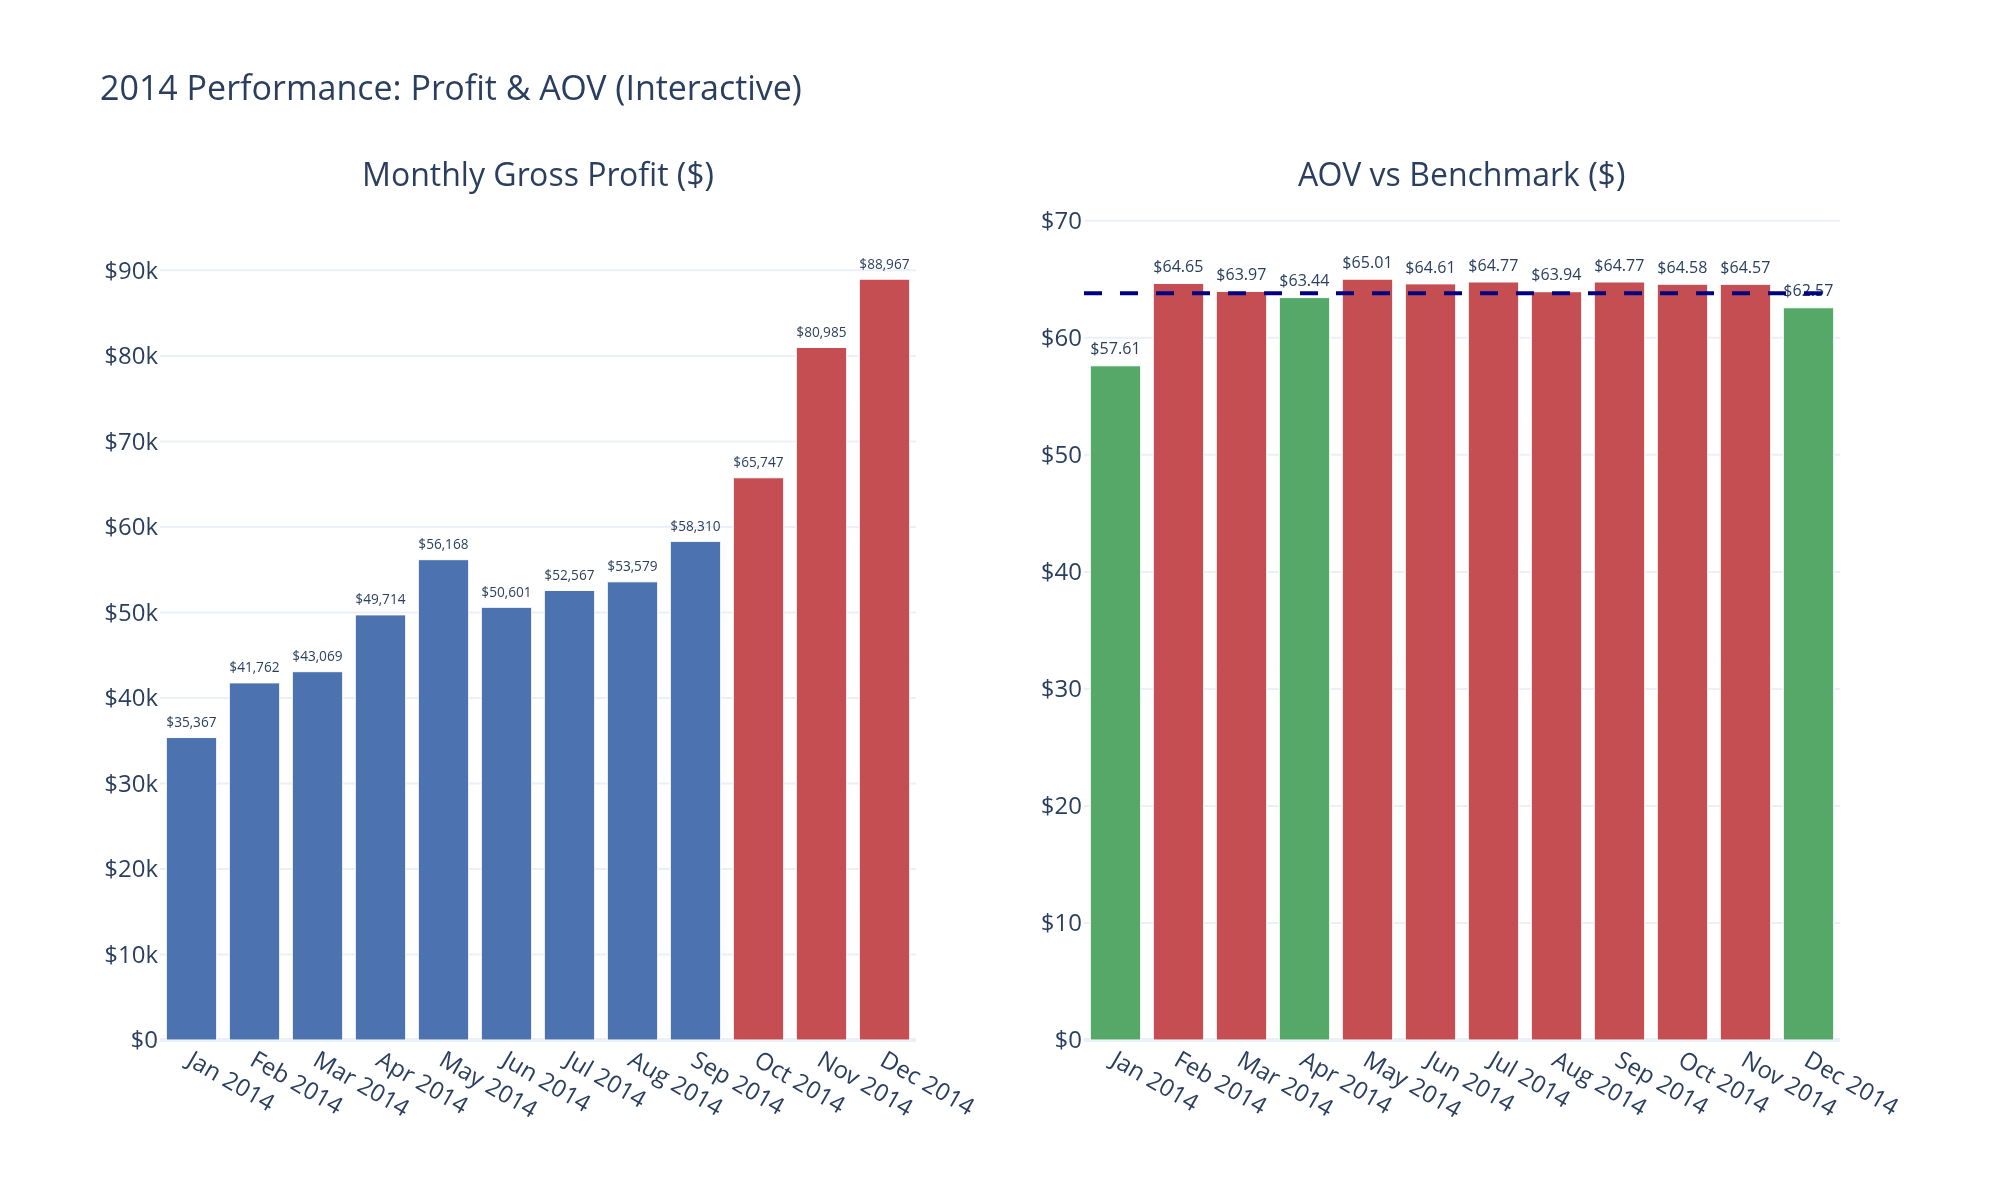

In [52]:
q3 = con_duck.execute("""
    SELECT
        DATE_TRUNC('month', o.created_at::TIMESTAMP)::DATE AS month,
        COUNT(DISTINCT o.order_id) AS total_orders,
        SUM(oi.price_usd) AS revenue,
        SUM(oi.price_usd - oi.cogs_usd) AS gross_profit,
        ROUND(SUM(oi.price_usd) / NULLIF(COUNT(DISTINCT o.order_id), 0), 2) AS aov
    FROM orders AS o 
    JOIN order_items oi USING (order_id)
    WHERE o.created_at::TIMESTAMP BETWEEN '2014-01-01' AND '2014-12-31'
    GROUP BY 1 
    ORDER BY 1
""").df()
q3['month'] = pd.to_datetime(q3['month'])
q3['month_str'] = q3['month'].dt.strftime('%b %Y')
top3_profit_val = q3['gross_profit'].nlargest(3).min()
aov_avg = 63.80

pio.renderers.default = "png"
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=('Monthly Gross Profit ($)', 'AOV vs Benchmark ($)'))

fig.add_trace(
    go.Bar(x=q3['month_str'], y=q3['gross_profit'],
           marker_color=['#C44E52' if v >= top3_profit_val else '#4C72B0' for v in q3['gross_profit']],
           text=q3['gross_profit'], texttemplate='$%{text:,.0f}', textposition='outside'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=q3['month_str'], y=q3['aov'],
           marker_color=['#C44E52' if v > aov_avg else '#55A868' for v in q3['aov']],
           text=q3['aov'], texttemplate='$%{text:.2f}', textposition='outside'),
    row=1, col=2
)

fig.add_hline(y=aov_avg, line_dash="dash", line_color="navy", row=1, col=2)

fig.update_layout(title_text='2014 Performance: Profit & AOV (Interactive)', template='plotly_white', showlegend=False)
fig.update_yaxes(tickprefix="$")
fig.show(renderer="png", width=1000, height=600, scale=2)

#### Group 2 — Product Performance

**Q4 — Despite ranking 4th in total revenue, were there specific weeks in 2014 where 'The Hudson River Mini Bear' outsold 'The Forever Love Bear'?**

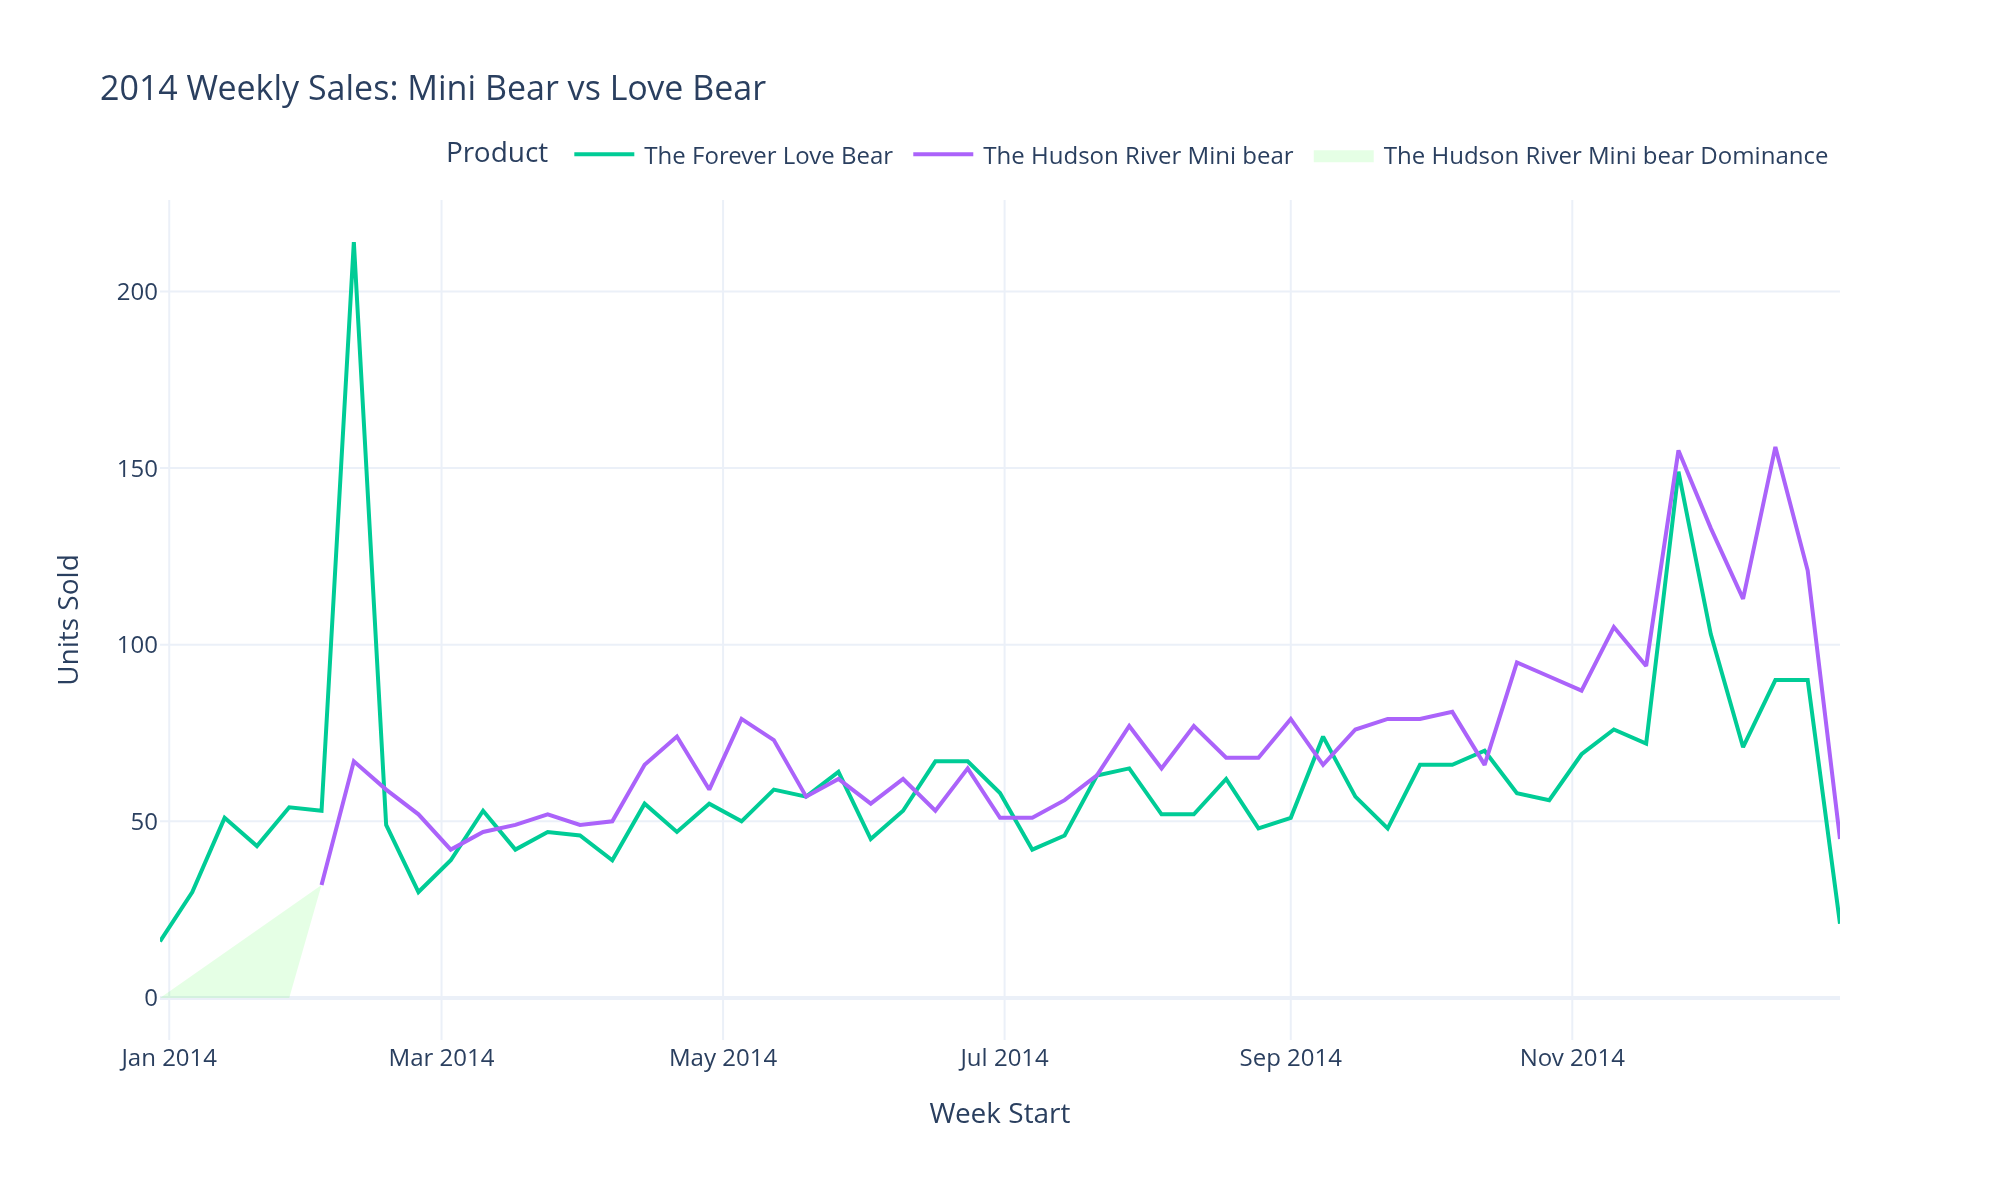

In [53]:
q4 = """
    SELECT
        DATE_TRUNC('week', o.created_at::TIMESTAMP)::DATE AS week_start,
        p.product_name,
        COUNT(oi.order_item_id) AS items_sold
    FROM order_items AS oi JOIN products AS p USING (product_id)
    JOIN orders AS o USING (order_id)
    WHERE o.created_at::TIMESTAMP BETWEEN '2014-01-01' AND '2014-12-31'
      AND (p.product_name ILIKE '%Mini Bear%' OR p.product_name ILIKE '%Love Bear%')
    GROUP BY 1, 2 
    ORDER BY 1
"""
df = con_duck.execute(q4).df()

pio.renderers.default = "png"
fig = px.line(df, x='week_start', y='items_sold', color='product_name',
              title='2014 Weekly Sales: Mini Bear vs Love Bear',
              color_discrete_map={
                  'The Hudson River Mini Bear': '#4C72B0',
                  'The Loving Sugar Love Bear': '#DD8452'
              },
              labels={'week_start': 'Week Start', 'items_sold': 'Units Sold', 'product_name': 'Product'})


pivot = df.pivot(index='week_start', columns='product_name', values='items_sold').fillna(0)
mini_col = [c for c in pivot.columns if 'Mini' in c][0]
love_col = [c for c in pivot.columns if 'Love' in c][0]

fig.add_trace(go.Scatter(
    x=pivot.index, 
    y=pivot[mini_col],
    fill='tonexty',
    fillcolor='rgba(0, 255, 0, 0.1)',
    line_color='rgba(255,255,255,0)',
    name=f'{mini_col} Dominance',
    showlegend=True
))

fig.update_layout(
    hovermode='x unified',
    template='plotly_white',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show(renderer="png", width=1000, height=600, scale=2)

**Q5 — After the launch of 'The Birthday Sugar Panda' in early 2014, how many days did it take to reach its first 100 orders?**

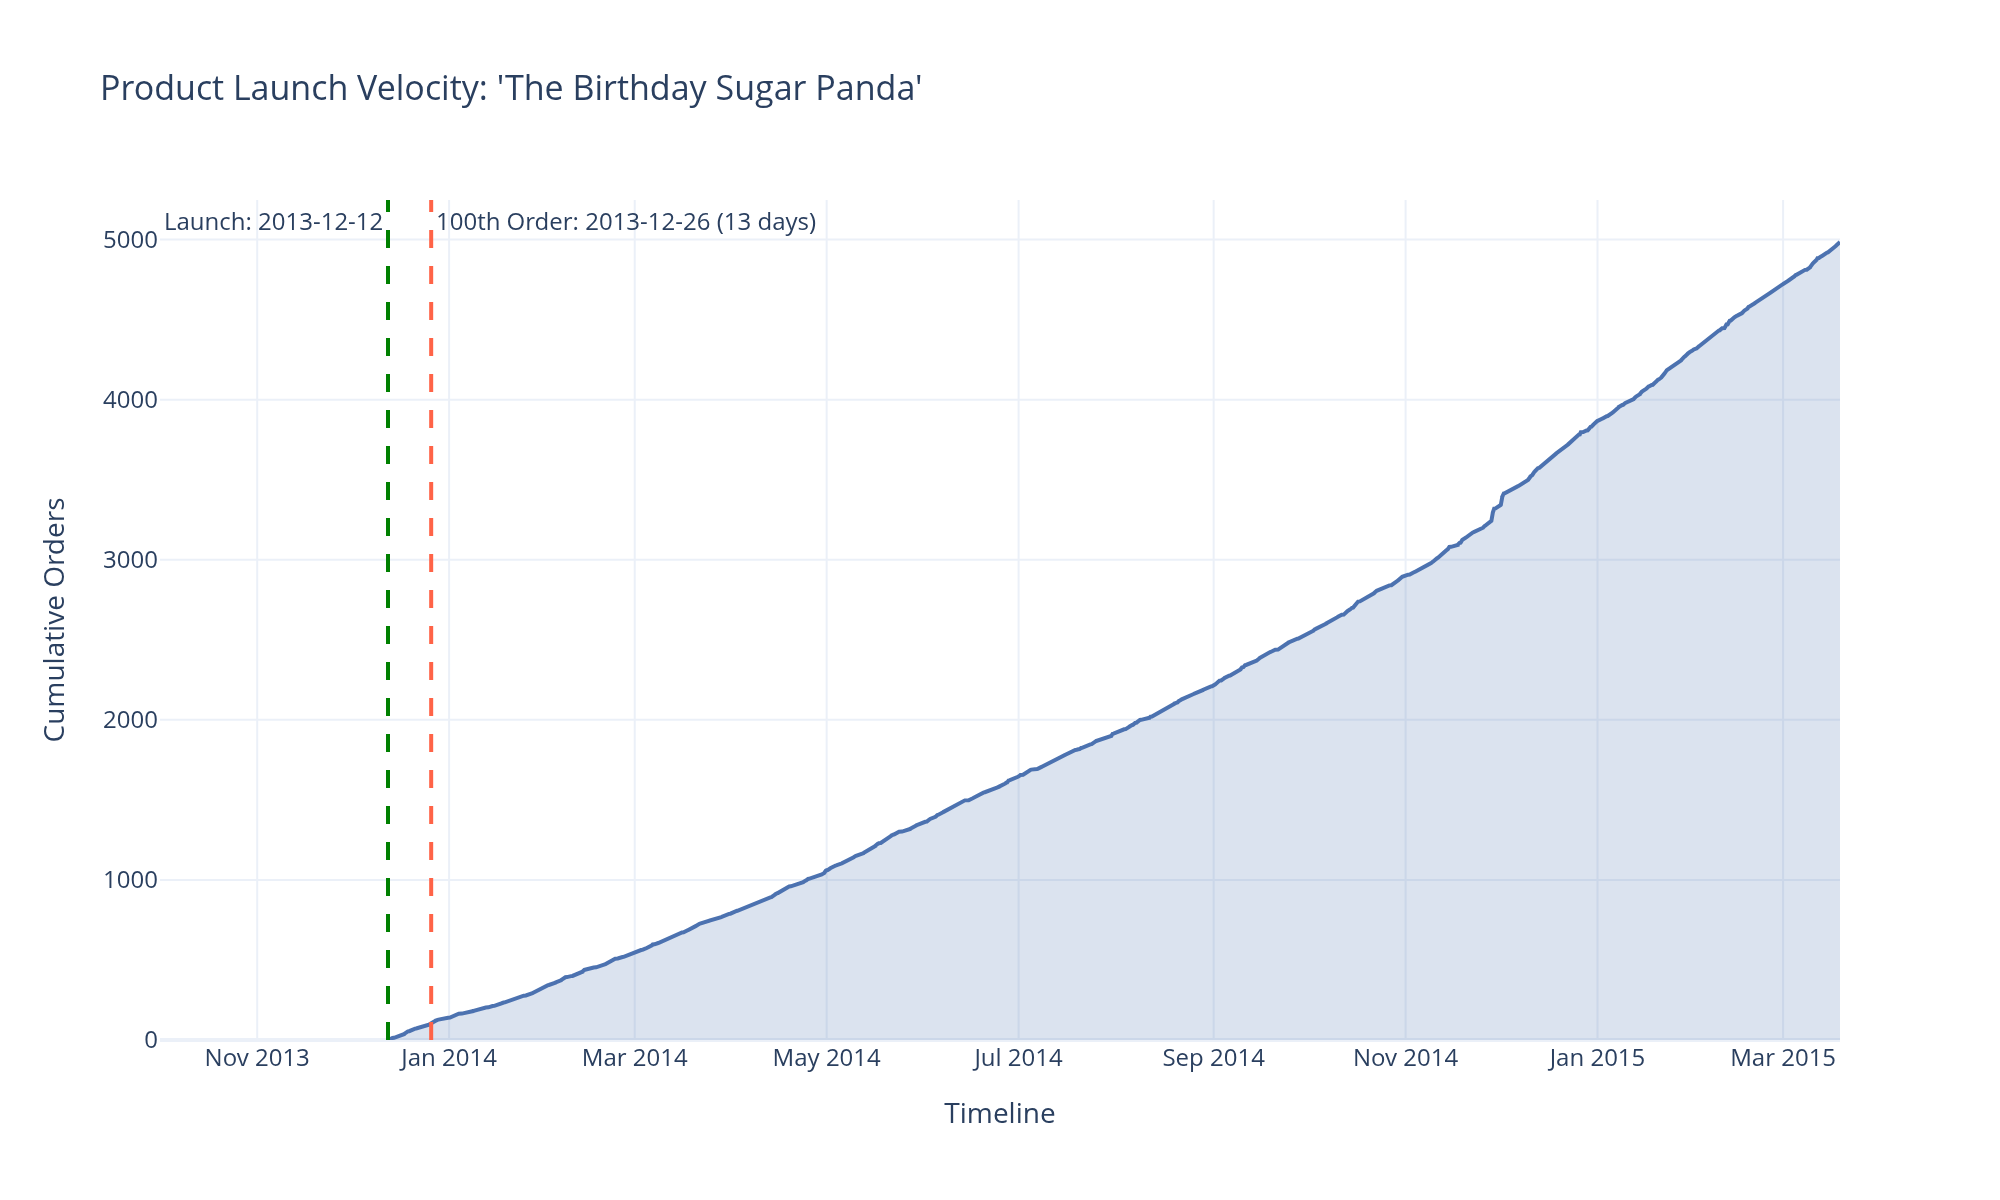

In [54]:
q5 = con_duck.execute("""
    SELECT
        o.created_at::TIMESTAMP AS created_at,
        ROW_NUMBER() OVER (ORDER BY o.created_at) AS order_num
    FROM order_items AS oi 
    JOIN products AS p USING (product_id)
    JOIN orders AS o USING (order_id)
    WHERE p.product_name = 'The Birthday Sugar Panda'
    ORDER BY o.created_at
""").df()
launch_date = q5['created_at'].min()
order_100_date = q5[q5['order_num'] == 100]['created_at'].iloc[0]
days_to_100 = (order_100_date - launch_date).days
launch_ts = launch_date.timestamp() * 1000
order_100_ts = order_100_date.timestamp() * 1000

pio.renderers.default = "png"
fig = px.area(q5, x='created_at', y='order_num', 
              title="Product Launch Velocity: 'The Birthday Sugar Panda'",
              labels={'created_at': 'Timeline', 'order_num': 'Cumulative Orders'})

fig.add_vline(x=launch_ts, line_dash="dash", line_color="green",
              annotation_text=f"Launch: {launch_date.date()}", 
              annotation_position="top left")

fig.add_vline(x=order_100_ts, line_dash="dash", line_color="tomato",
              annotation_text=f"100th Order: {order_100_date.date()} ({days_to_100} days)", 
              annotation_position="top right")

fig.update_traces(line_color='#4C72B0', fillcolor='rgba(76, 114, 176, 0.2)')
fig.update_layout(template='plotly_white', hovermode='x unified')

fig.show(renderer="png", width=1000, height=600, scale=2)

**Q6 — In Q4 2014 specifically, what was the cross-sell rate (orders with more than one item), and which product combinations were most common?**

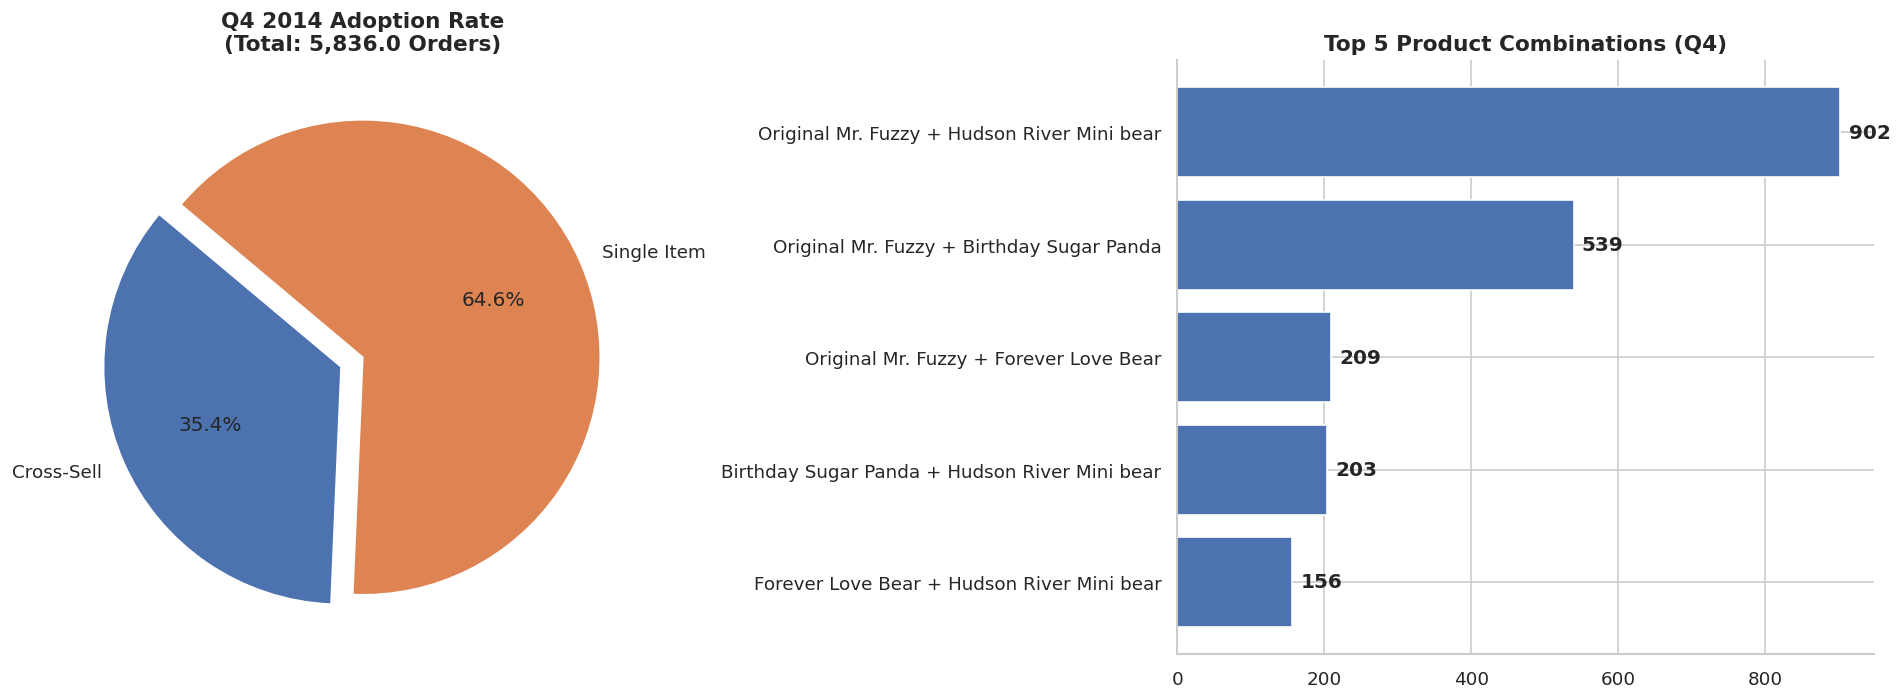

In [55]:
q6_rate = """
    WITH order_metrics AS (
        SELECT order_id, COUNT(order_item_id) AS items_count
        FROM order_items
        JOIN orders o USING (order_id)
        WHERE o.created_at BETWEEN '2014-10-01' AND '2014-12-31'
        GROUP BY 1
    )
    SELECT 
        COUNT(*) AS total_orders,
        COUNT(CASE WHEN items_count > 1 THEN 1 END) AS multi_item_orders,
        ROUND(COUNT(CASE WHEN items_count > 1 THEN 1 END) * 100.0 / NULLIF(COUNT(*), 0), 2) AS cross_sell_pct
    FROM order_metrics
"""
q6_combos = """
    SELECT
        REPLACE(p1.product_name, 'The ', '') || ' + ' || 
        REPLACE(p2.product_name, 'The ', '') AS combo_label,
        COUNT(*) AS combo_count
    FROM order_items oi1
    JOIN order_items oi2 ON oi1.order_id = oi2.order_id AND oi1.product_id < oi2.product_id
    JOIN products p1     ON oi1.product_id = p1.product_id
    JOIN products p2     ON oi2.product_id = p2.product_id
    JOIN orders o        ON oi1.order_id   = o.order_id
    WHERE o.created_at BETWEEN '2014-10-01' AND '2014-12-31'
    GROUP BY 1 
    ORDER BY 2 DESC
    LIMIT 5
"""
df_rate = con_duck.execute(q6_rate).df()
df_combos = con_duck.execute(q6_combos).df()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

rate_data = df_rate.iloc[0]
sizes = [rate_data['multi_item_orders'], rate_data['total_orders'] - rate_data['multi_item_orders']]
ax1.pie(sizes, labels=['Cross-Sell', 'Single Item'], autopct='%1.1f%%', 
        startangle=140, colors=['#4C72B0', '#DD8452'], explode=(0.1, 0))
ax1.set_title(f"Q4 2014 Adoption Rate\n(Total: {rate_data['total_orders']:,} Orders)", fontweight='bold')

bars = ax2.barh(df_combos['combo_label'], df_combos['combo_count'], color='#4C72B0')
ax2.bar_label(bars, padding=5, fontweight='bold')
ax2.invert_yaxis()
ax2.set_title('Top 5 Product Combinations (Q4)', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

#### Group 3 — Traffic & Conversion

**Q7 — In October and November 2014, did gsearch nonbrand maintain its all-time conversion rate of 6.66%, or was there a seasonal improvement or decline?**

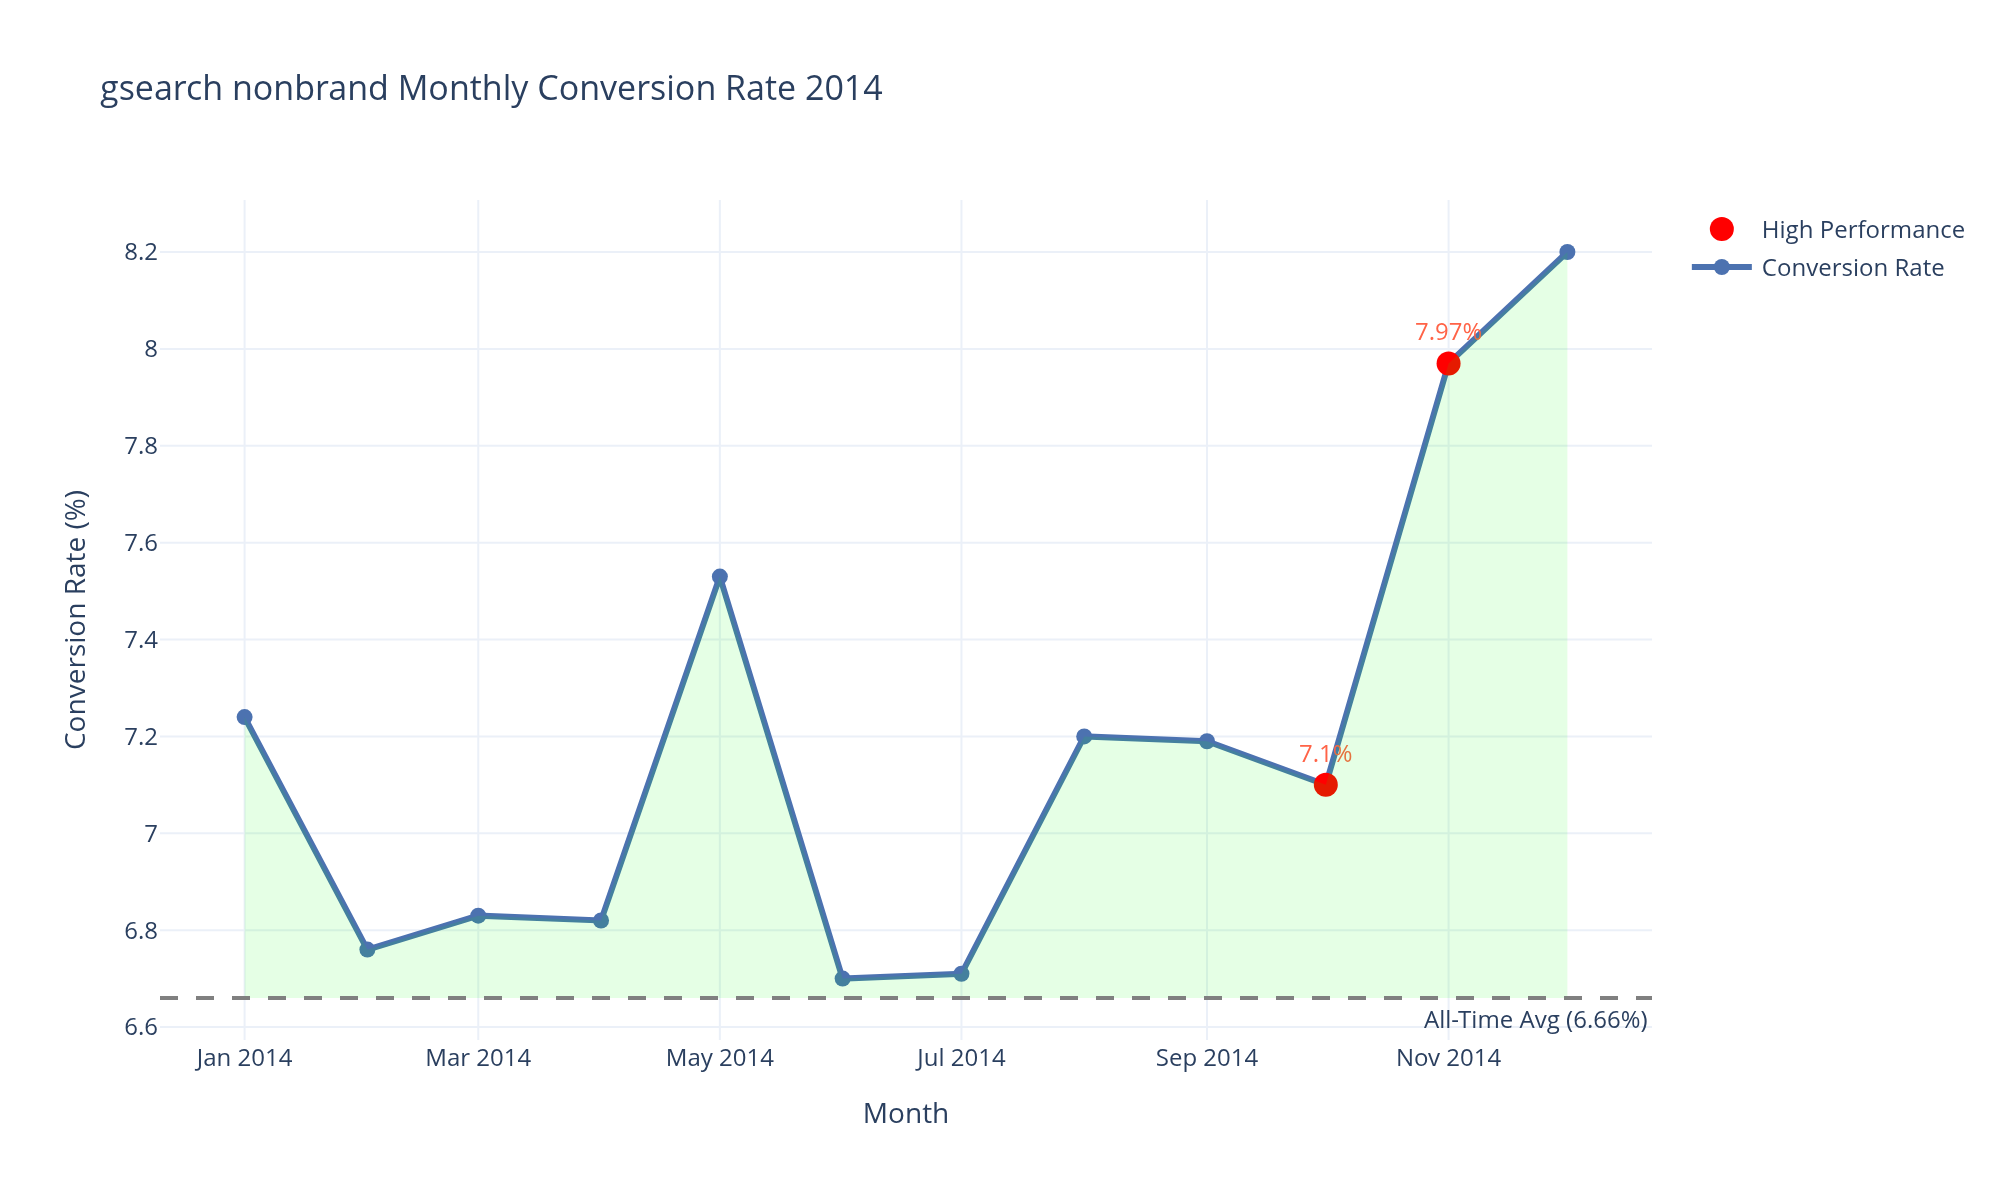

In [56]:
q7 = con_duck.execute("""
    SELECT
        DATE_TRUNC('month', s.created_at::TIMESTAMP)::DATE AS month,
        COUNT(DISTINCT s.website_session_id) AS sessions,
        COUNT(DISTINCT o.order_id) AS orders,
        ROUND(COUNT(DISTINCT o.order_id) * 100.0 / COUNT(DISTINCT s.website_session_id), 2) AS conv_rate_pct
    FROM website_sessions AS s LEFT JOIN orders AS o
    ON s.website_session_id = o.website_session_id
    WHERE s.utm_source   = 'gsearch'
      AND s.utm_campaign = 'nonbrand'
      AND YEAR(s.created_at::TIMESTAMP) = 2014
    GROUP BY 1 ORDER BY 1
""").df()

q7['month'] = pd.to_datetime(q7['month'])
baseline = 6.66

pio.renderers.default = "png"
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=q7['month'], y=q7['conv_rate_pct'],
    mode='lines+markers',
    name='Conversion Rate',
    line=dict(color='#4C72B0', width=3),
    marker=dict(size=8)
))

fig.add_hline(y=baseline, line_dash="dash", line_color="gray", 
              annotation_text=f"All-Time Avg ({baseline}%)", 
              annotation_position="bottom right")

highlight = q7[q7['month'].dt.month.isin([10, 11])]
fig.add_trace(go.Scatter(
    x=highlight['month'], y=highlight['conv_rate_pct'],
    mode='markers+text',
    name='High Performance',
    marker=dict(color='red', size=12, symbol='circle'),
    text=highlight['conv_rate_pct'].apply(lambda x: f"{x}%"),
    textposition="top center",
    textfont=dict(color='tomato', size=12)
))

fig.add_trace(go.Scatter(
    x=q7['month'], y=[baseline] * len(q7),
    fill=None, mode='lines', line_color='rgba(0,0,0,0)', showlegend=False
))
fig.add_trace(go.Scatter(
    x=q7['month'], y=q7['conv_rate_pct'],
    fill='tonexty', 
    fillcolor='rgba(0, 255, 0, 0.1)',
    mode='none', name='Above/Below Baseline', showlegend=False
))

fig.update_layout(
    title='gsearch nonbrand Monthly Conversion Rate 2014',
    xaxis_title='Month',
    yaxis_title='Conversion Rate (%)',
    template='plotly_white',
    hovermode='x unified'
)

fig.show(renderer="png", width=1000, height=600, scale=2)

**Q8 — In the first three months of 2013, what was the conversion rate gap between desktop and mobile for the gsearch nonbrand campaign specifically?**

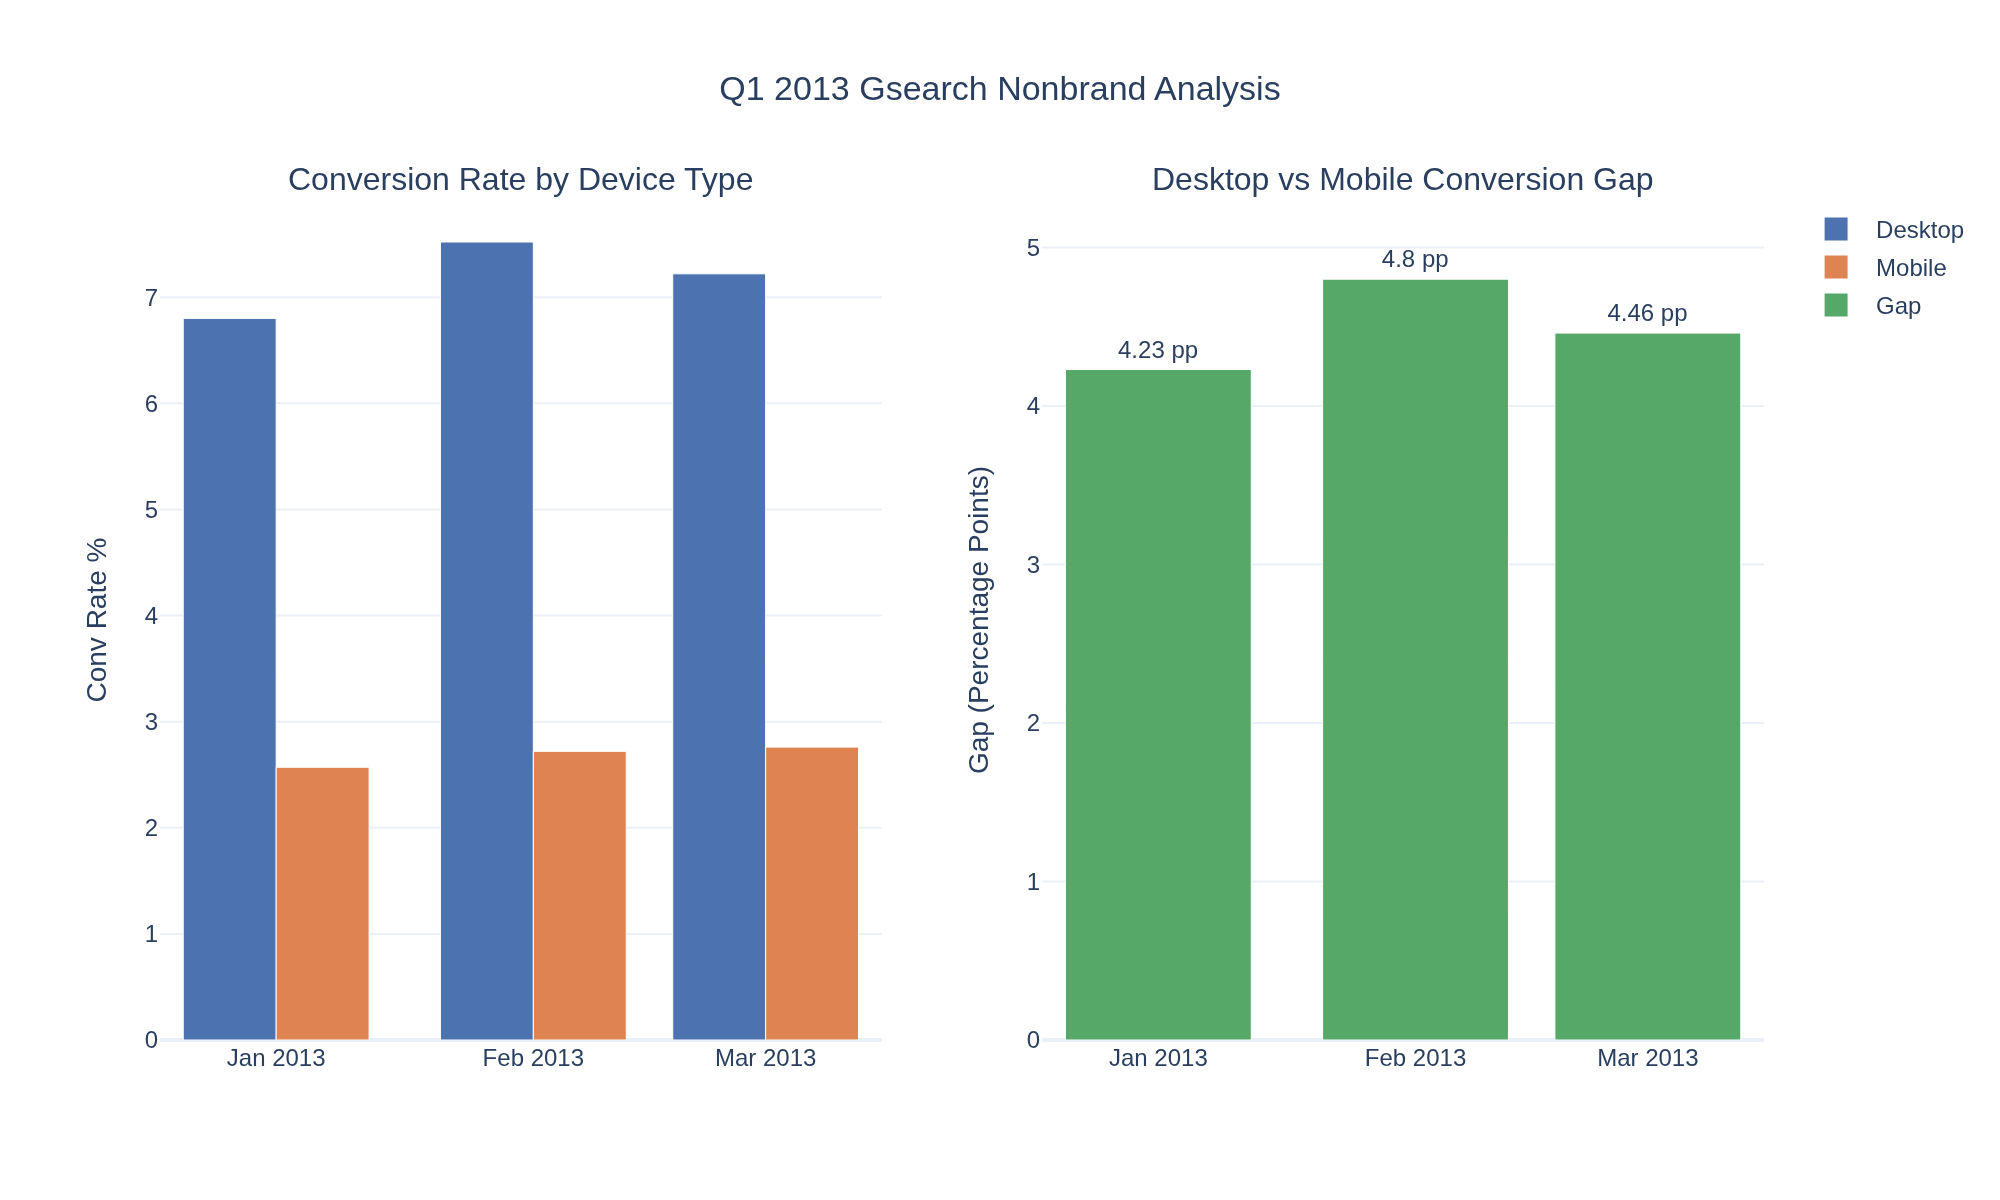

In [57]:
q8 = con_duck.execute("""
    SELECT
        DATE_TRUNC('month', s.created_at::TIMESTAMP)::DATE AS month,
        s.device_type,
        COUNT(DISTINCT s.website_session_id) AS sessions,
        COUNT(DISTINCT o.order_id) AS orders,
        ROUND(COUNT(DISTINCT o.order_id) * 100.0 / NULLIF(COUNT(DISTINCT s.website_session_id), 0), 2) AS conv_rate_pct
    FROM website_sessions s
    LEFT JOIN orders o USING (website_session_id)
    WHERE s.utm_source = 'gsearch'
      AND s.utm_campaign = 'nonbrand'
      AND s.created_at BETWEEN '2013-01-01' AND '2013-03-31'
    GROUP BY 1, 2 
    ORDER BY 1, 2
""").df()
pivot8 = q8.pivot(index='month', columns='device_type', values='conv_rate_pct').fillna(0)
pivot8.index = pivot8.index.astype(str)
pivot8['gap'] = pivot8['desktop'] - pivot8['mobile']

pio.renderers.default = "png"
fig = make_subplots(
    rows=1, cols=2, 
    subplot_titles=('Conversion Rate by Device Type', 'Desktop vs Mobile Conversion Gap')
)

fig.add_trace(
    go.Bar(x=pivot8.index, y=pivot8['desktop'], name='Desktop', marker_color='#4C72B0'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=pivot8.index, y=pivot8['mobile'], name='Mobile', marker_color='#DD8452'),
    row=1, col=1
)

gap_colors = ['#C44E52' if v > 5 else '#55A868' for v in pivot8['gap']]
fig.add_trace(
    go.Bar(
        x=pivot8.index, 
        y=pivot8['gap'], 
        marker_color=gap_colors,
        text=pivot8['gap'].round(2).astype(str) + " pp",
        textposition='outside',
        name='Gap'
    ),
    row=1, col=2
)
fig.update_layout(
    height=500, 
    width=1100, 
    showlegend=True,
    template='plotly_white',
    title_text="Q1 2013 Gsearch Nonbrand Analysis",
    title_x=0.5,
    font=dict(family="Arial", size=12)
)

fig.update_yaxes(title_text="Conv Rate %", row=1, col=1)
fig.update_yaxes(title_text="Gap (Percentage Points)", row=1, col=2)

fig.show(renderer="png", width=1000, height=600, scale=2)

#### Group 4 — Device & Session Behavior

**Q9 — In 2012, was the mobile vs desktop conversion rate gap already as wide as the all-time gap (3.09% vs 8.50%), or were the two devices closer in performance at the start?**

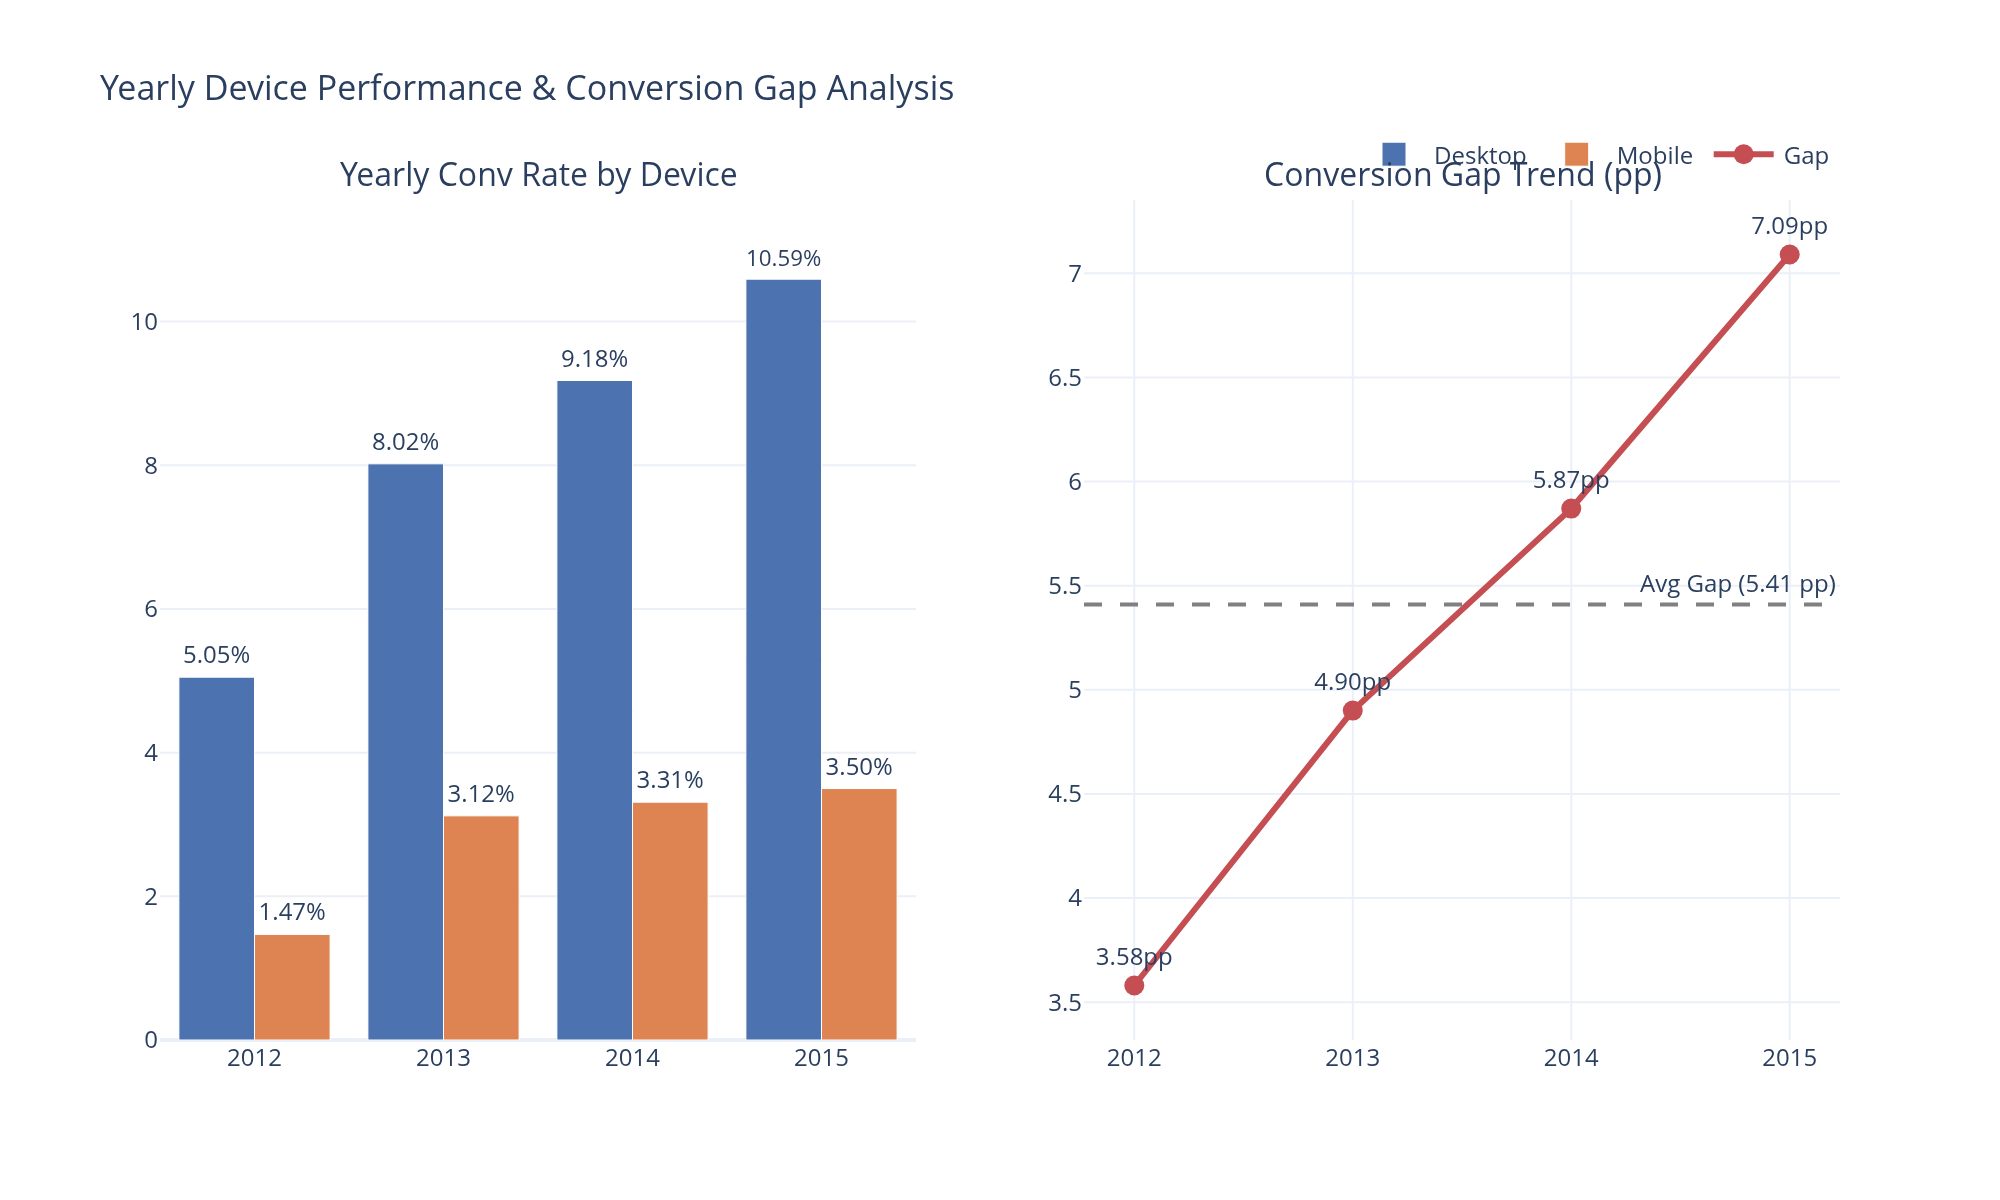

In [58]:
q9 = con_duck.execute("""
    SELECT
        EXTRACT(YEAR FROM s.created_at::TIMESTAMP) AS year,
        s.device_type,
        COUNT(DISTINCT s.website_session_id) AS sessions,
        COUNT(DISTINCT o.order_id) AS orders,
        ROUND(COUNT(DISTINCT o.order_id) * 100.0
              / COUNT(DISTINCT s.website_session_id), 2) AS conv_rate_pct
    FROM website_sessions s
    LEFT JOIN orders o ON s.website_session_id = o.website_session_id
    GROUP BY 1, 2 ORDER BY 1, 2
""").df()

pivot9 = q9.pivot(index='year', columns='device_type', values='conv_rate_pct').fillna(0)
pivot9['gap'] = pivot9['desktop'] - pivot9['mobile']
avg_gap = 5.41

pio.renderers.default = "png"
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=('Yearly Conv Rate by Device', 'Conversion Gap Trend (pp)'))

fig.add_trace(
    go.Bar(x=pivot9.index, y=pivot9['desktop'], name='Desktop', 
           marker_color='#4C72B0', text=pivot9['desktop'], 
           texttemplate='%{text:.2f}%', textposition='outside'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=pivot9.index, y=pivot9['mobile'], name='Mobile', 
           marker_color='#DD8452', text=pivot9['mobile'], 
           texttemplate='%{text:.2f}%', textposition='outside'),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=pivot9.index, y=pivot9['gap'], name='Gap',
               mode='lines+markers+text',
               line=dict(color='#C44E52', width=3),
               marker=dict(size=10),
               text=pivot9['gap'], texttemplate='%{text:.2f}pp', textposition='top center'),
    row=1, col=2
)

fig.add_hline(y=avg_gap, line_dash="dash", line_color="gray", 
              annotation_text=f"Avg Gap ({avg_gap} pp)", row=1, col=2)

fig.update_layout(
    title_text='Yearly Device Performance & Conversion Gap Analysis',
    template='plotly_white',
    barmode='group',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.update_xaxes(type='category')
fig.show(renderer="png", width=1000, height=600, scale=2)

**Q10 — In 2014, which day of the week had the highest desktop session volume, and did it also correspond to the highest desktop conversion rate?**

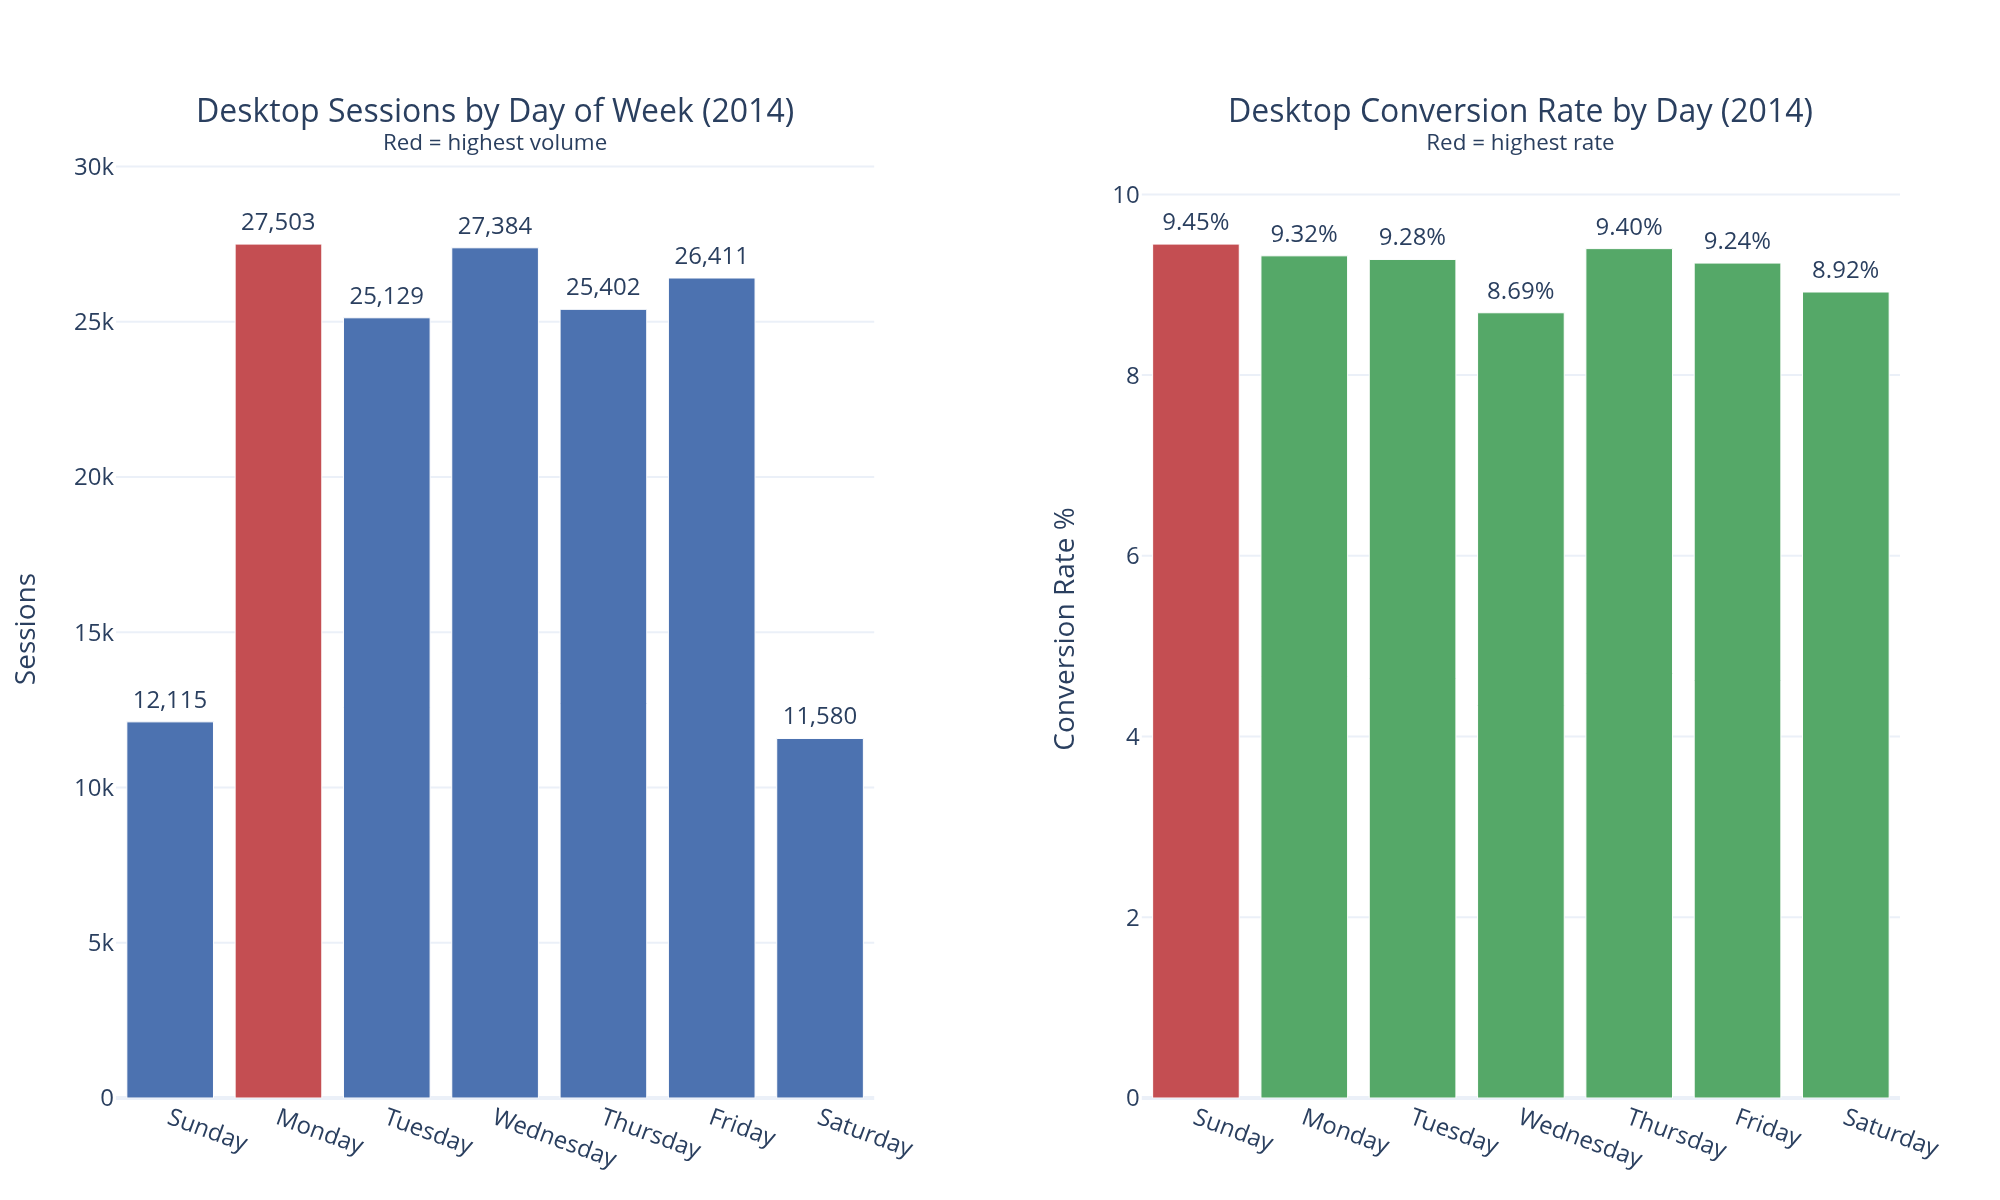

In [59]:
q10 = con_duck.execute("""
    SELECT 
        DAYOFWEEK(CAST(s.created_at AS TIMESTAMP)) AS day_num,
        STRFTIME(CAST(s.created_at AS TIMESTAMP), '%A') AS day_name,
        COUNT(DISTINCT s.website_session_id) AS sessions,
        COUNT(DISTINCT o.order_id) AS orders,
        ROUND(COUNT(DISTINCT o.order_id) * 100.0 
              / COUNT(DISTINCT s.website_session_id), 2) AS conv_rate_pct
    FROM website_sessions s
    LEFT JOIN orders o ON s.website_session_id = o.website_session_id
    WHERE s.device_type = 'desktop'
      AND YEAR(CAST(s.created_at AS TIMESTAMP)) = 2014
    GROUP BY 1, 2 
    ORDER BY 1
""").df()

colors_sessions = ['#C44E52' if v == q10['sessions'].max() else '#4C72B0' for v in q10['sessions']]
colors_conv = ['#C44E52' if v == q10['conv_rate_pct'].max() else '#55A868' for v in q10['conv_rate_pct']]

pio.renderers.default = "png"
fig = make_subplots(
    rows=1, cols=2, 
    subplot_titles=(
        'Desktop Sessions by Day of Week (2014)<br><sup>Red = highest volume</sup>', 
        'Desktop Conversion Rate by Day (2014)<br><sup>Red = highest rate</sup>'
    ),
    horizontal_spacing=0.15
)

fig.add_trace(
    go.Bar(
        x=q10['day_name'], 
        y=q10['sessions'], 
        marker_color=colors_sessions,
        text=q10['sessions'].apply(lambda x: f"{x:,.0f}"),
        textposition='outside',
        name='Sessions'
    ),
    row=1, col=1
)
fig.add_trace(
    go.Bar(
        x=q10['day_name'], 
        y=q10['conv_rate_pct'], 
        marker_color=colors_conv,
        text=q10['conv_rate_pct'].apply(lambda x: f"{x:.2f}%"),
        textposition='outside',
        name='Conv Rate %'
    ),
    row=1, col=2
)

fig.update_layout(
    height=500,
    width=1100,
    template='plotly_white',
    showlegend=False,
    margin=dict(t=80, b=50, l=50, r=50)
)

fig.update_xaxes(tickangle=20)
fig.update_yaxes(title_text="Sessions", row=1, col=1)
fig.update_yaxes(title_text="Conversion Rate %", row=1, col=2)

fig.show(renderer="png", width=1000, height=600, scale=2)

#### Group 5 — Refunds & Risk

**Q11 — What was the monthly refund distribution across 2014, and were there any months with a refund rate spike above the all-time average of 4.4%?**

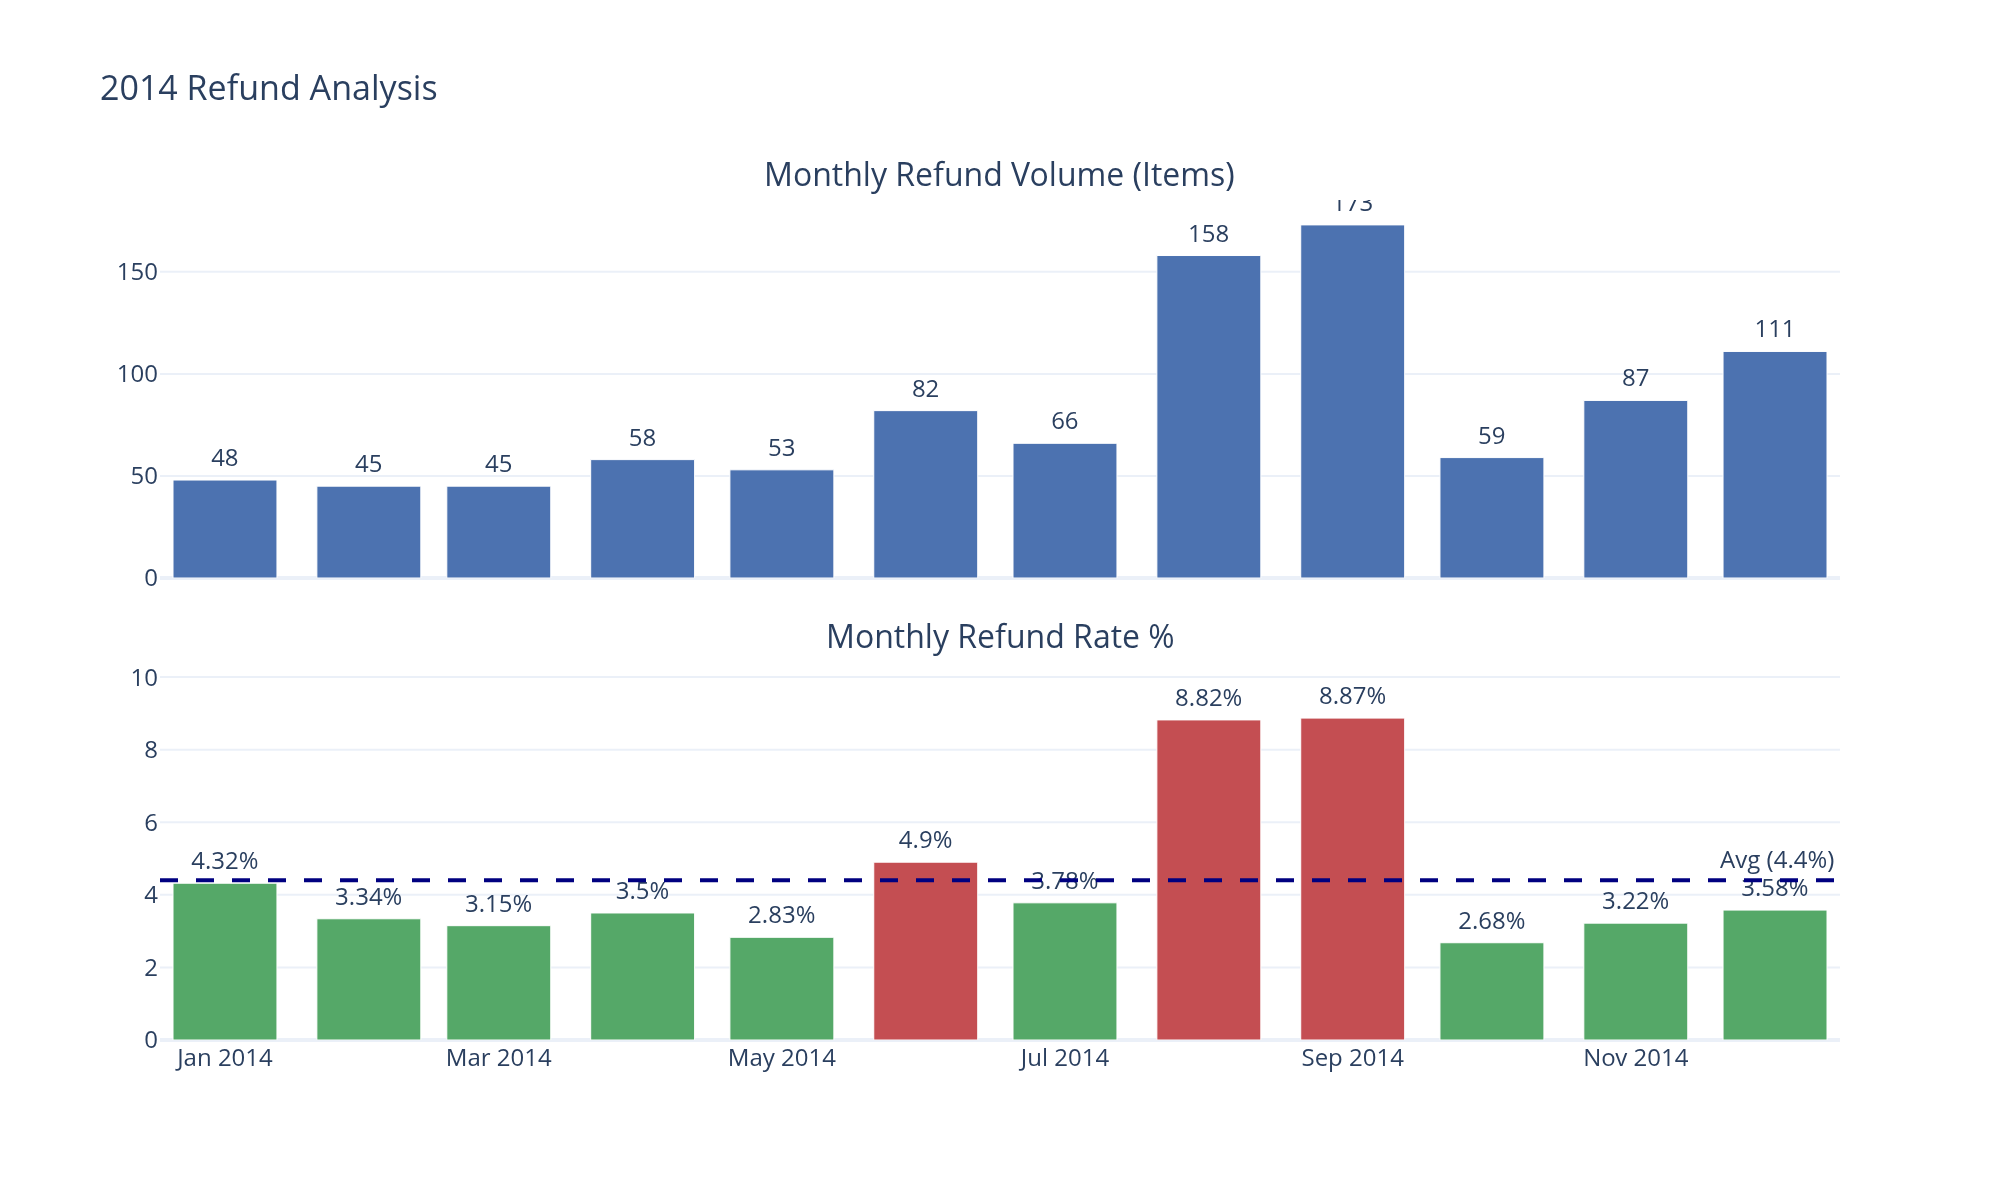

In [60]:
q11 = con_duck.execute("""
    SELECT 
        STRFTIME(CAST(o.created_at AS TIMESTAMP), '%Y-%m') AS month,
        COUNT(oi.order_item_id) AS items_sold,
        COUNT(oir.order_item_refund_id) AS refunds,
        ROUND(COUNT(oir.order_item_refund_id) * 100.0 / COUNT(oi.order_item_id), 2) AS refund_rate_pct,
        ROUND(COALESCE(SUM(oir.refund_amount_usd), 0), 2) AS refund_amount
    FROM order_items oi
    JOIN orders o ON oi.order_id = o.order_id
    LEFT JOIN order_item_refunds oir ON oi.order_item_id = oir.order_item_id
    WHERE YEAR(CAST(o.created_at AS TIMESTAMP)) = 2014 -- تحويل النوع هنا
    GROUP BY 1 
    ORDER BY 1
""").df()
avg_refund = 4.4
spike_colors = ['#C44E52' if v > avg_refund else '#55A868' for v in q11['refund_rate_pct']]

pio.renderers.default = "png"
fig = make_subplots(
    rows=2, cols=1, 
    shared_xaxes=True, 
    vertical_spacing=0.1,
    subplot_titles=('Monthly Refund Volume (Items)', 'Monthly Refund Rate %')
)

fig.add_trace(
    go.Bar(
        x=q11['month'], 
        y=q11['refunds'], 
        marker_color='#4C72B0',
        text=q11['refunds'],
        textposition='outside',
        name='Refunds'
    ),
    row=1, col=1
)
fig.add_trace(
    go.Bar(
        x=q11['month'], 
        y=q11['refund_rate_pct'], 
        marker_color=spike_colors,
        text=q11['refund_rate_pct'].apply(lambda x: f"{x}%"),
        textposition='outside',
        name='Refund Rate %'
    ),
    row=2, col=1
)

fig.add_hline(y=avg_refund, line_dash="dash", line_color="navy",annotation_text=f"Avg ({avg_refund}%)", row=2, col=1)

fig.update_layout(height=700, title_text="2014 Refund Analysis", template="plotly_white", showlegend=False)
fig.show(renderer="png", width=1000, height=600, scale=2)

**Q12 — What is the individual refund rate for 'The Original Mr. Fuzzy' (highest volume, 24,226 items) vs 'The Birthday Sugar Panda' (highest margin, 68.49%)?**

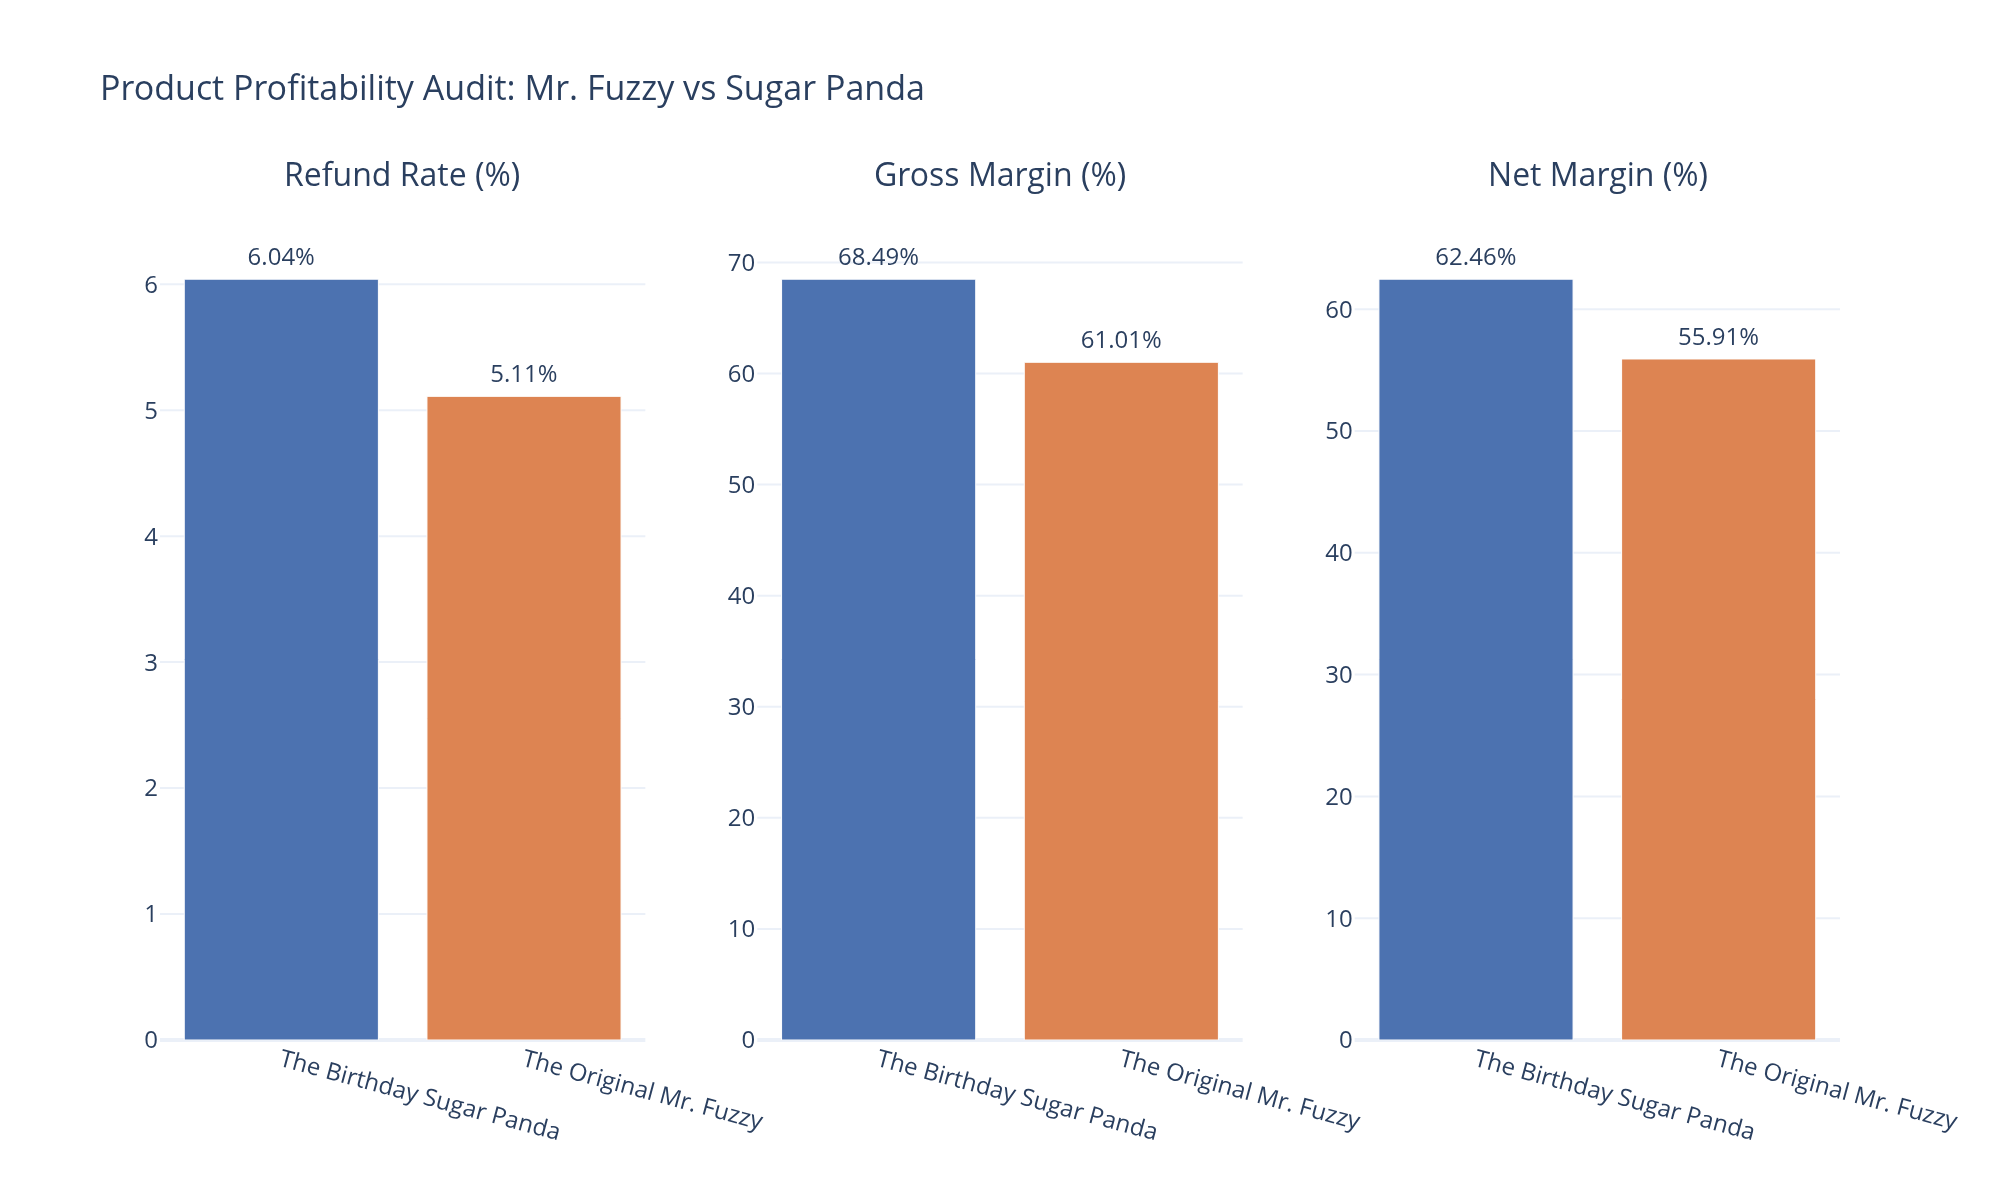

In [61]:
q12 = con_duck.execute("""
    SELECT
        p.product_name,
        COUNT(oi.order_item_id) AS items_sold,
        COUNT(oir.order_item_refund_id) AS refunds,
        ROUND(COUNT(oir.order_item_refund_id) * 100.0 / COUNT(oi.order_item_id), 2) AS refund_rate_pct,
        ROUND(
            (SUM(oi.price_usd - oi.cogs_usd) / NULLIF(SUM(oi.price_usd), 0)) * 100, 2
        ) AS gross_margin_pct,
        ROUND(
            (SUM(oi.price_usd - oi.cogs_usd) - COALESCE(SUM(oir.refund_amount_usd), 0))
            / NULLIF(SUM(oi.price_usd), 0) * 100, 2
        ) AS net_margin_pct
    FROM order_items oi
    JOIN products p USING (product_id)
    LEFT JOIN order_item_refunds oir USING (order_item_id)
    WHERE p.product_name IN ('The Original Mr. Fuzzy', 'The Birthday Sugar Panda')
    GROUP BY 1
""").df()
metrics = [
    ('refund_rate_pct',  'Refund Rate (%)'),
    ('gross_margin_pct', 'Gross Margin (%)'),
    ('net_margin_pct',   'Net Margin (%)')
]

pio.renderers.default = "png"
fig = make_subplots(rows=1, cols=3, subplot_titles=[m[1] for m in metrics])
colors = ['#4C72B0', '#DD8452']

for i, (col_name, title) in enumerate(metrics, 1):
    fig.add_trace(
        go.Bar(
            x=q12['product_name'], 
            y=q12[col_name],
            marker_color=colors,
            text=q12[col_name],
            texttemplate='%{text:.2f}%',
            textposition='outside',
            name=title,
            showlegend=False
        ),
        row=1, col=i
    )
fig.update_layout(
    title_text='Product Profitability Audit: Mr. Fuzzy vs Sugar Panda',
    template='plotly_white',
    height=500
)

fig.update_xaxes(tickangle=15)
fig.show(renderer="png", width=1000, height=600, scale=2)

#### Group 6 — Growth & Anomalies

**Q13 — The 2015 data ends in March, causing a misleading −68.36% YoY growth. What is the true Q1-to-Q1 growth rate when comparing Q1 2015 vs Q1 2014?**

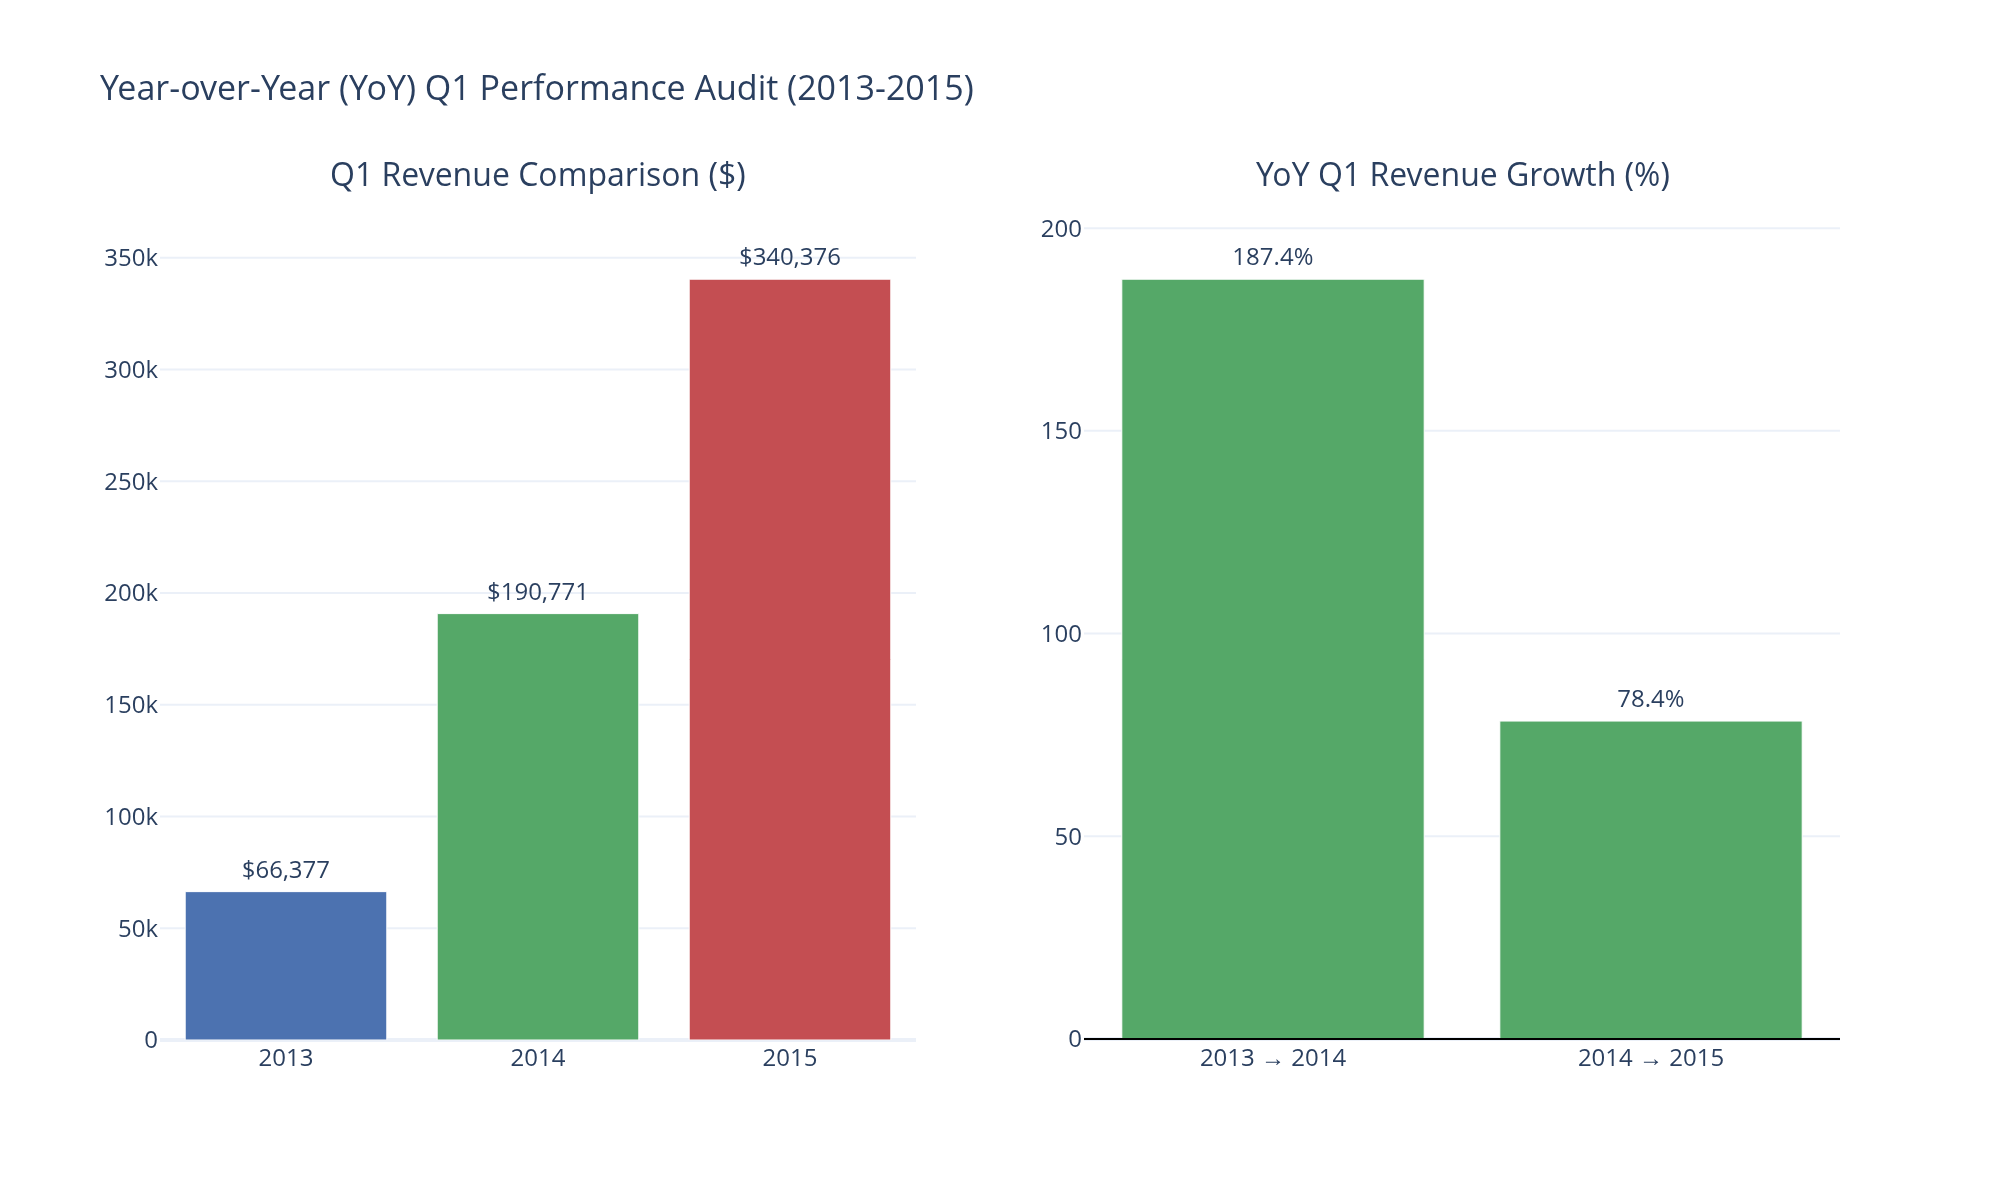

In [62]:
q13 = con_duck.execute("""
    SELECT
        EXTRACT(YEAR FROM o.created_at::TIMESTAMP) AS year,
        COUNT(DISTINCT o.order_id) AS total_orders,
        ROUND(SUM(oi.price_usd), 2) AS revenue
    FROM orders AS o 
    JOIN order_items AS oi USING (order_id)
    WHERE MONTH(o.created_at::TIMESTAMP) BETWEEN 1 AND 3
      AND EXTRACT(YEAR FROM o.created_at::TIMESTAMP) IN (2013, 2014, 2015)
    GROUP BY 1 ORDER BY 1
""").df()
q13['revenue_growth_pct'] = q13['revenue'].pct_change() * 100

growth_df = q13.dropna(subset=['revenue_growth_pct']).copy()
growth_df['label'] = growth_df['year'].apply(lambda x: f"{int(x-1)} → {int(x)}")

pio.renderers.default = "png"
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=('Q1 Revenue Comparison ($)', 'YoY Q1 Revenue Growth (%)'))

fig.add_trace(
    go.Bar(x=q13['year'].astype(str), y=q13['revenue'],
           marker_color=['#4C72B0', '#55A868', '#C44E52'],
           text=q13['revenue'], texttemplate='$%{text:,.0f}', textposition='outside',
           name='Revenue'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=growth_df['label'], y=growth_df['revenue_growth_pct'],
           marker_color=['#55A868' if v > 0 else '#C44E52' for v in growth_df['revenue_growth_pct']],
           text=growth_df['revenue_growth_pct'], texttemplate='%{text:.1f}%', textposition='outside',
           name='Growth Rate'),
    row=1, col=2
)

fig.update_layout(
    title_text='Year-over-Year (YoY) Q1 Performance Audit (2013-2015)',
    template='plotly_white',
    showlegend=False,
    height=500
)

fig.add_hline(y=0, line_color="black", line_width=1, row=1, col=2)
fig.show(renderer="png", width=1000, height=600, scale=2)

**Q14 — What were the top 5 highest revenue days across all three years, and are they clustered in the same seasonal periods or spread across different windows?**

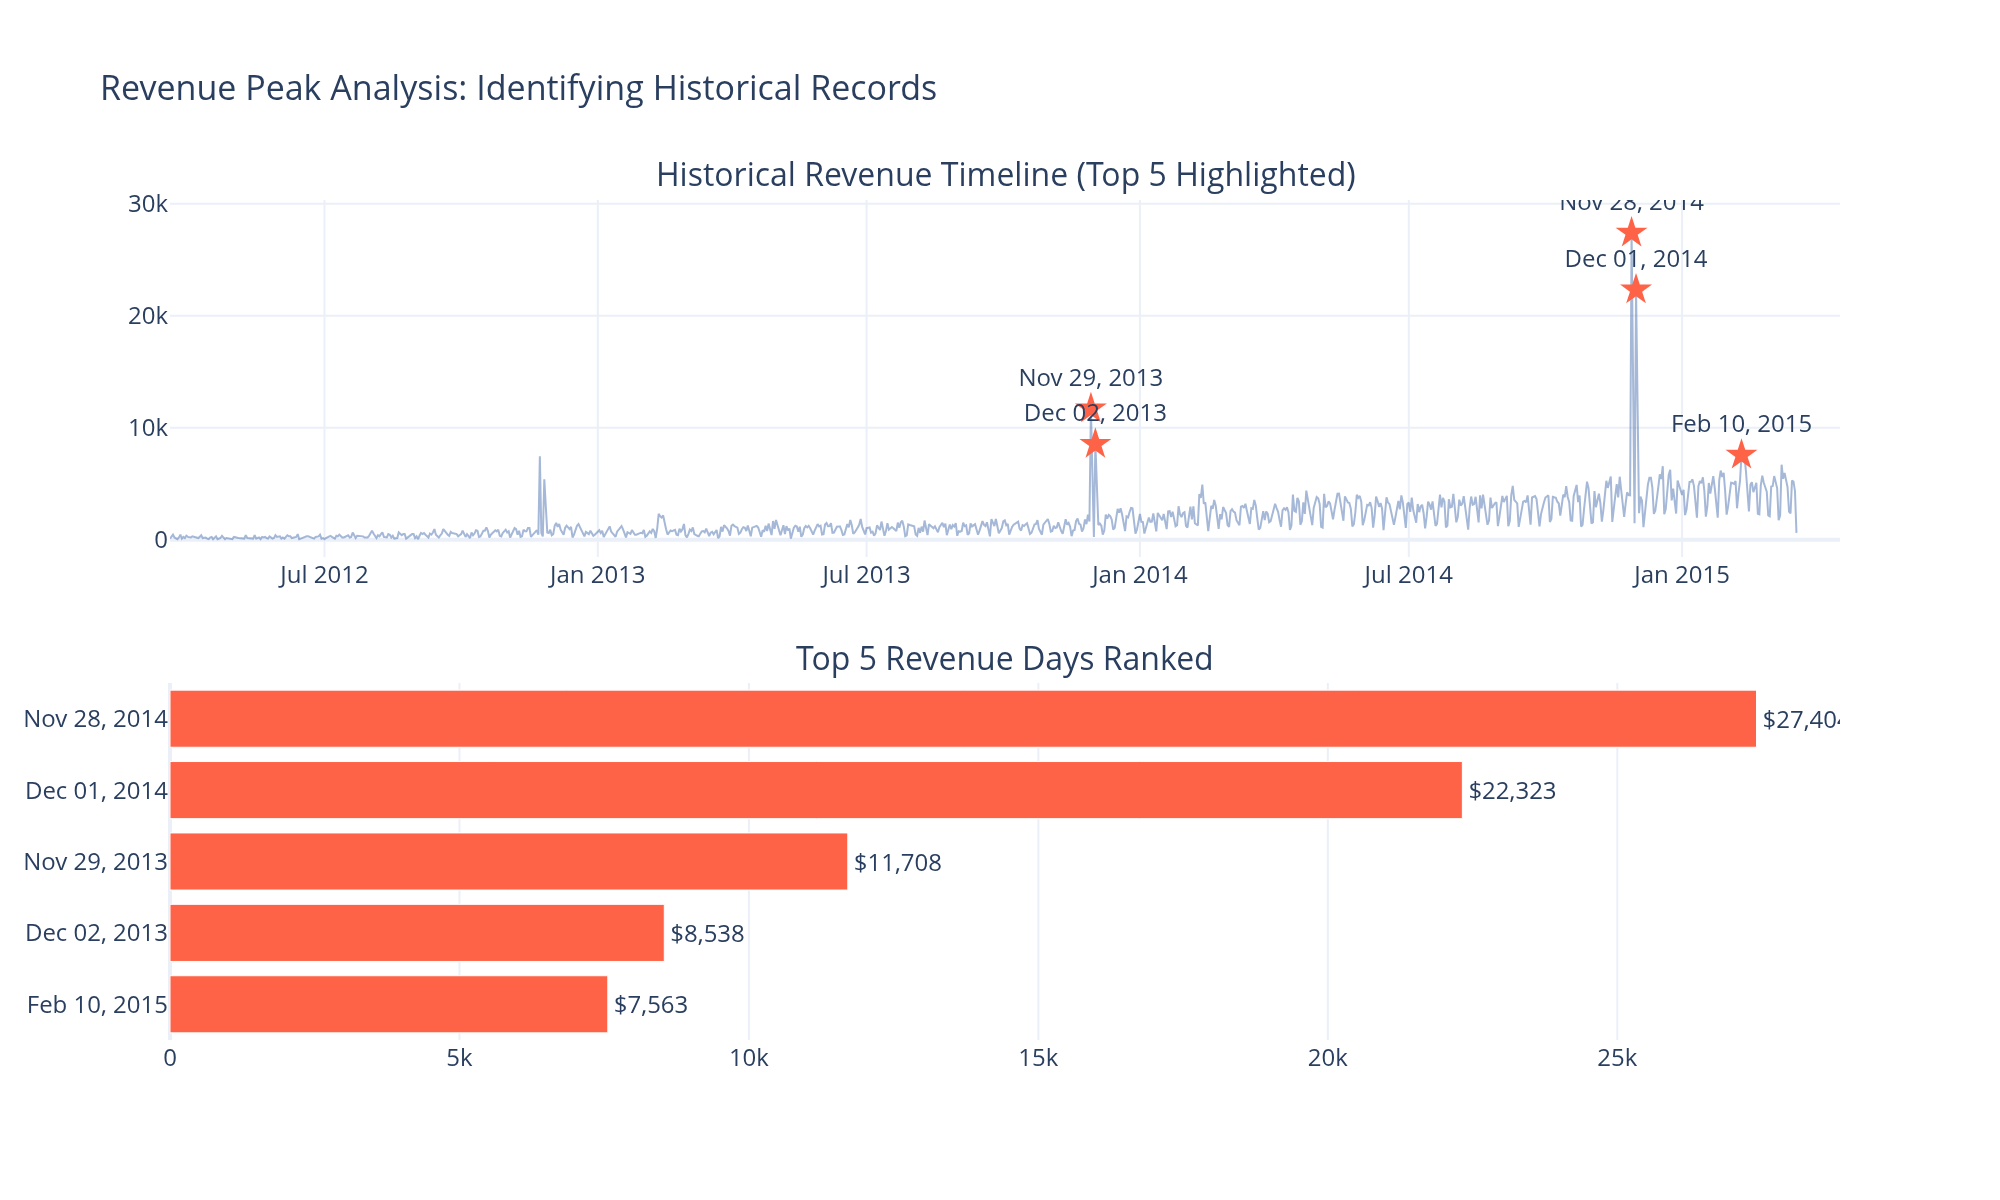

In [63]:
q14 = con_duck.execute("""
    SELECT
        DATE_TRUNC('day', o.created_at::TIMESTAMP)::DATE AS sale_date,
        COUNT(DISTINCT o.order_id) AS total_orders,
        ROUND(SUM(oi.price_usd), 2) AS revenue
    FROM orders AS o JOIN order_items AS oi USING (order_id)
    GROUP BY 1 ORDER BY revenue DESC
    LIMIT 5
""").df()
q14['label'] = pd.to_datetime(q14['sale_date']).dt.strftime('%b %d, %Y')

daily_all = con_duck.execute("""
    SELECT
        DATE_TRUNC('day', o.created_at::TIMESTAMP)::DATE AS sale_date,
        ROUND(SUM(oi.price_usd), 2) AS revenue
    FROM orders o JOIN order_items oi USING (order_id)
    GROUP BY 1 ORDER BY 1
""").df()

pio.renderers.default = "png"
fig = make_subplots(rows=2, cols=1, 
                    vertical_spacing=0.15,
                    subplot_titles=('Historical Revenue Timeline (Top 5 Highlighted)', 
                                    'Top 5 Revenue Days Ranked'))

fig.add_trace(
    go.Scatter(x=daily_all['sale_date'], y=daily_all['revenue'],
               mode='lines', name='Daily Revenue',
               line=dict(color='#4C72B0', width=1),
               opacity=0.5),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=q14['sale_date'], y=q14['revenue'],
               mode='markers+text', name='Peak Days',
               marker=dict(color='tomato', size=12, symbol='star'),
               text=q14['label'], textposition='top center',
               hovertemplate='<b>%{text}</b><br>Revenue: $%{y:,.2f}<extra></extra>'),
    row=1, col=1
)

fig.add_trace(
    go.Bar(x=q14['revenue'], y=q14['label'],
           orientation='h', name='Ranked Peaks',
           marker_color='tomato',
           text=q14['revenue'], texttemplate='$%{text:,.0f}', textposition='outside'),
    row=2, col=1
)

fig.update_layout(
    title_text='Revenue Peak Analysis: Identifying Historical Records',
    template='plotly_white',
    height=800,
    showlegend=False
)

fig.update_yaxes(autorange="reversed", row=2, col=1)
fig.show(renderer="png", width=1000, height=600, scale=2)